# Imports

In [269]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
device = torch.device('cuda:0' if torch.cuda.is_available else 'cpu')
device

device(type='cuda', index=0)

# Data

## Text

In [270]:
txt = '''
Lorem ipsum dolor sit amet, consectetur adipiscing elit. Integer egestas odio est, a elementum lacus laoreet quis. Pellentesque sit amet nisi erat. Morbi quis nisl odio. Quisque nec nibh consequat, congue ex ut, imperdiet ipsum. Integer nec ornare orci, id interdum arcu. Mauris odio sapien, semper vitae consectetur eget, porttitor a purus. Donec ultrices gravida mauris, id convallis nunc malesuada nec. Integer consequat, diam non fermentum hendrerit, nisi lorem ultrices ante, id consequat elit libero eu magna. Aenean molestie, ipsum vel porttitor pellentesque, mi mauris dignissim nulla, sed tristique libero risus quis erat. Aliquam turpis lacus, venenatis at odio et, volutpat scelerisque sapien.

Ut ac sem arcu. Integer feugiat ac nisi ut vestibulum. Vivamus laoreet nisi eu iaculis fringilla. Maecenas ultrices a orci id mattis. In rhoncus malesuada nunc vel placerat. Suspendisse felis diam, lacinia sit amet fringilla at, viverra eu eros. Nulla vulputate felis vel turpis sagittis gravida. Curabitur id sapien ante. Vestibulum fringilla sem iaculis dictum cursus. Sed elit lacus, consequat placerat ligula sit amet, commodo accumsan metus. Suspendisse sollicitudin orci leo, a pretium augue tempor porttitor. Duis lectus nisl, semper at nulla non, vestibulum vehicula dolor.

Nulla suscipit fringilla lectus non dictum. Integer mollis quam et quam ultricies, eu tempus massa auctor. Fusce eget nisi dui. In fermentum enim sit amet massa tempus molestie. Vestibulum pellentesque euismod maximus. In porttitor urna et rutrum mollis. Vivamus vel lectus dolor. Mauris libero nisl, pulvinar vitae posuere eget, venenatis id odio. Quisque massa ante, convallis eget facilisis ut, lacinia id tortor. Donec interdum urna et velit aliquam, a pharetra ex fringilla. Ut at accumsan libero. Interdum et malesuada fames ac ante ipsum primis in faucibus. Vivamus fringilla sed risus ac facilisis. Quisque euismod bibendum sem, eget aliquet justo.

Morbi faucibus ante id libero malesuada porttitor. Praesent feugiat tempus feugiat. Vestibulum at placerat risus. Nulla facilisi. Mauris lacinia enim sollicitudin mauris cursus, egestas hendrerit massa bibendum. Maecenas interdum massa eu maximus pharetra. Aliquam egestas, ante in malesuada hendrerit, odio felis posuere lectus, non ultricies lectus orci et metus. Phasellus venenatis sem ac nisl posuere, in auctor urna dapibus. Aliquam tincidunt, lacus a fermentum bibendum, nunc ligula posuere ex, eu sodales urna nisl sit amet ipsum.

Vivamus faucibus lorem non tellus suscipit maximus. Quisque porta suscipit mi ac condimentum. Aenean aliquet nunc quis sapien pellentesque ultricies. Vivamus fringilla arcu vitae cursus sodales. Maecenas ultricies laoreet metus et mattis. In a consequat nisl, tincidunt ultricies ligula. Nunc ipsum mauris, tempus et mollis vehicula, ultrices in lacus. In ipsum diam, iaculis id bibendum vel, congue et velit. Donec non eros semper lectus ornare laoreet. Etiam scelerisque eu mi sit amet efficitur. In libero turpis, sollicitudin non tristique ut, hendrerit quis diam. Orci varius natoque penatibus et magnis dis parturient montes, nascetur ridiculus mus. Etiam vitae metus et tellus tristique tempor a nec ligula. Praesent pretium lorem in ornare vestibulum.

Integer porta nisi massa, ac vulputate nisl vestibulum quis. Duis viverra vitae lectus vitae rutrum. Duis ac arcu porttitor, fermentum justo eu, bibendum libero. Duis ultricies, enim non lobortis placerat, enim est bibendum enim, posuere placerat augue ante nec magna. Nunc lacinia lorem eu metus sodales, eu fringilla dui euismod. Praesent eu hendrerit sem, laoreet aliquam mi. Integer in leo et mauris imperdiet tincidunt eu vel nisl. Nam interdum non lectus vel congue.

Vivamus pharetra ultrices finibus. Donec auctor est nec faucibus eleifend. Fusce nulla dolor, porta at dolor eu, faucibus lobortis lorem. Morbi pharetra volutpat nibh quis ultrices. Aenean ut justo ut lorem molestie fringilla. Maecenas quis massa sem. Morbi luctus risus non nunc fermentum, eu auctor est consectetur. Integer ullamcorper nec ante vitae pellentesque. Donec quis malesuada ex. Etiam ornare sagittis luctus. Orci varius natoque penatibus et magnis dis parturient montes, nascetur ridiculus mus.

Donec massa orci, lobortis ac commodo vitae, tincidunt ac arcu. Curabitur nec metus lacinia lacus tristique mollis et eu mauris. Curabitur at dolor risus. Maecenas scelerisque nunc eu vulputate maximus. Nunc dignissim sem semper scelerisque dignissim. Duis facilisis purus elit, ornare semper dui eleifend sit amet. Aliquam erat volutpat. Proin quis finibus enim, interdum malesuada enim. Fusce porta ex nunc, at tincidunt nulla pellentesque vel. Nulla bibendum tincidunt neque eu lobortis.

Aenean vitae nulla ut lectus semper congue. Curabitur at tellus at eros aliquet viverra. Mauris finibus ante quis neque mattis, eget tempor nisl mollis. Nam sagittis neque tortor, vitae hendrerit dui viverra ac. Praesent ipsum nisi, iaculis in convallis sit amet, condimentum vitae ligula. Interdum et malesuada fames ac ante ipsum primis in faucibus. Aliquam erat volutpat. Donec vestibulum nec nulla at ornare.

Pellentesque lobortis enim leo, vel egestas ipsum sagittis a. Proin nec massa in mauris varius tincidunt. Quisque non varius erat, vel dapibus augue. Integer imperdiet pulvinar lectus sed gravida. Etiam lacinia leo eu arcu tincidunt luctus. Maecenas egestas pretium sapien vel dictum. Aenean ultricies tellus eu magna consectetur elementum. Etiam ut vulputate dolor, id venenatis lectus. Donec vehicula a enim ut faucibus. Duis feugiat tellus id porttitor finibus. Vestibulum aliquet mauris massa, vel iaculis erat ultricies at. Quisque fermentum venenatis orci sed volutpat. Praesent ullamcorper quam risus, eleifend commodo metus porta eget. Nam gravida mattis elit a dignissim. Vivamus euismod dapibus lacus, in eleifend ante efficitur eu.

Praesent mattis, lorem ac efficitur aliquam, lorem eros bibendum tortor, at euismod magna sem eu nisl. Suspendisse gravida lobortis risus ultricies pretium. Morbi vel dui sit amet neque pellentesque malesuada eu ut justo. Donec maximus pretium ante, ut congue dolor placerat id. Etiam blandit, nibh eget luctus mattis, ex risus aliquam metus, luctus gravida sem ante eget quam. Vivamus ut scelerisque odio, id efficitur nunc. Etiam orci mauris, fermentum a metus dictum, consequat fermentum dolor. Curabitur tincidunt diam turpis, vitae maximus nibh imperdiet ac. Fusce posuere quis leo eget iaculis. Morbi nec nunc ante. Suspendisse pulvinar imperdiet pharetra. Cras quis vulputate nisl.

Vestibulum sed felis nec tortor egestas ornare non porta lectus. Etiam volutpat euismod sodales. Vestibulum sodales bibendum volutpat. Sed ullamcorper nulla est, sed tempus leo congue nec. Pellentesque porta est ac turpis porta viverra. Cras aliquam, libero id efficitur mollis, nisi ex fringilla turpis, eu rhoncus sapien libero id quam. Vestibulum efficitur mollis tellus et faucibus. Curabitur vulputate ex ut arcu lobortis efficitur. Pellentesque pretium venenatis consectetur. Integer vestibulum odio sed orci tempor blandit. Nam non neque ac justo aliquam mattis at id nisi. Donec et fringilla purus. Nunc fringilla ante eu lacinia hendrerit. Quisque tempus, arcu at rhoncus dignissim, odio libero interdum purus, a placerat arcu neque ut ipsum. Vestibulum ante ipsum primis in faucibus orci luctus et ultrices posuere cubilia curae; Integer id volutpat risus, in molestie dui.

Mauris sed nibh commodo, vehicula dolor sit amet, porttitor leo. Curabitur mattis eu nisi ac luctus. In elit lorem, condimentum scelerisque aliquet ut, tincidunt a sem. Fusce bibendum massa justo, in rhoncus est varius sed. Orci varius natoque penatibus et magnis dis parturient montes, nascetur ridiculus mus. Vivamus condimentum, nisl ac tincidunt consequat, erat dui dapibus eros, quis aliquam diam tortor ac tortor. Aliquam sit amet lobortis lacus. Duis finibus felis iaculis felis suscipit, vel interdum massa sodales. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Proin mattis dolor ligula, eleifend maximus mi posuere nec.

Nulla vel mollis mi. Vivamus gravida vitae leo eu eleifend. Fusce quis facilisis nisl, at egestas lectus. Praesent eleifend justo eget ligula posuere, et luctus dui viverra. Suspendisse et odio molestie, consequat neque in, malesuada mauris. Suspendisse tincidunt, nisl et interdum suscipit, turpis ex fermentum velit, vel malesuada metus elit non mauris. Curabitur elit metus, facilisis scelerisque erat placerat, lobortis suscipit purus. Proin bibendum massa dui, in condimentum urna fermentum quis. Morbi mattis felis sed volutpat ultrices. Praesent nec placerat erat. Fusce quis bibendum neque, ut venenatis elit.

Proin sollicitudin, lorem nec hendrerit posuere, leo massa condimentum arcu, in mollis nunc risus nec dui. Pellentesque habitant morbi tristique senectus et netus et malesuada fames ac turpis egestas. Fusce laoreet lacus sed lorem imperdiet pretium. Donec nibh lacus, pretium finibus neque id, condimentum suscipit sem. Sed congue vel nulla in dignissim. Nullam eu turpis non magna dictum auctor ut non lectus. Vestibulum tellus lacus, ultrices sed nunc ac, pretium ultrices quam. Duis justo ipsum, dapibus vel mattis at, convallis et orci. Maecenas interdum accumsan tempus. Pellentesque habitant morbi tristique senectus et netus et malesuada fames ac turpis egestas.

Pellentesque quis orci elit. Fusce sem purus, dignissim id luctus malesuada, convallis sed lectus. Suspendisse euismod bibendum finibus. Sed nulla enim, vehicula eget interdum vel, pulvinar viverra diam. Fusce iaculis odio ut turpis sodales maximus. Maecenas diam purus, interdum et erat nec, malesuada sodales lorem. Pellentesque ut felis bibendum ex tempus tincidunt. Donec rutrum sem vitae libero laoreet, vitae volutpat lectus finibus.

Fusce sed dui et nisi cursus interdum ut in nisl. Phasellus maximus ipsum eget lorem scelerisque interdum. Nam imperdiet tempus suscipit. Sed eros elit, ultrices eget mattis a, ultricies eget ante. Vivamus dapibus sapien at elit viverra viverra. Pellentesque in libero nec sem viverra iaculis ut vel quam. Maecenas vitae sapien pretium, rhoncus tellus a, volutpat orci.

Maecenas ut erat ut sem sollicitudin porta eu ut nunc. Sed ut nulla porta, porta nisi sed, posuere tellus. Ut id molestie velit. In venenatis eros purus, varius gravida elit ornare vitae. Etiam quis aliquet ligula, ac egestas nunc. Integer vitae tincidunt lacus. Aenean ornare metus sodales, ultricies purus sed, ultrices lorem. Phasellus consequat sapien quis est elementum, eget viverra purus sodales. Integer faucibus lectus id tellus cursus aliquet. Pellentesque nec cursus nisi. Quisque sit amet pretium mauris. Curabitur consectetur dolor sed magna maximus, ut semper sem ornare. Aliquam bibendum urna vel nibh consequat, ac consequat neque scelerisque. Ut commodo ante metus, suscipit tempus augue varius quis. Nunc sit amet neque aliquam arcu imperdiet congue.

Aenean quis velit sit amet justo volutpat auctor. Suspendisse eros velit, consectetur ac imperdiet ut, porta eu dolor. Sed quis nibh et leo condimentum pretium. In massa libero, consectetur bibendum neque ut, pulvinar imperdiet urna. Phasellus consequat, massa ut volutpat imperdiet, diam neque blandit sem, vel facilisis ex ex eget urna. Phasellus a nisi est. Pellentesque sed turpis at nisi pulvinar molestie quis a leo. In placerat eu nulla a posuere. Integer pulvinar augue ut orci bibendum, nec ullamcorper enim lobortis. Praesent non semper tortor, vel eleifend erat. Quisque a massa lectus. Maecenas eleifend accumsan turpis ut congue. Nulla iaculis finibus lectus, id viverra arcu sagittis non. Pellentesque semper eros at vestibulum dignissim. Duis interdum purus in elit faucibus lacinia. Nam volutpat ut neque ac ultricies.

Morbi quis orci risus. Sed blandit urna id dui blandit pellentesque. Donec sollicitudin urna tortor, non pretium sem maximus id. Ut varius volutpat volutpat. Duis et ipsum ac metus aliquam interdum at at diam. Nunc et dui et elit luctus cursus non sit amet lorem. Phasellus eget commodo dui, vel consequat dui.

Donec ac aliquam nisi, at consectetur orci. Morbi a facilisis felis. Nulla maximus molestie mollis. In hac habitasse platea dictumst. Nulla consectetur pellentesque enim sed tristique. Suspendisse ante nulla, tristique vitae hendrerit sit amet, posuere nec orci. Quisque eget tincidunt urna, ut tempor diam. Integer mollis nunc sit amet sem pretium ullamcorper. Suspendisse vel faucibus enim. Quisque vel tellus aliquet, consectetur diam a, egestas sapien. Interdum et malesuada fames ac ante ipsum primis in faucibus. Mauris porta, est sed commodo varius, metus nisi viverra arcu, ut rutrum metus arcu a metus. Vestibulum ut pharetra leo, eu scelerisque dolor.

Sed ex risus, imperdiet vel est non, facilisis auctor nisi. Sed efficitur ex vel mauris malesuada faucibus. Maecenas vel tortor sed enim mollis aliquam. Nulla facilisi. Sed cursus consequat odio in lobortis. Suspendisse potenti. Quisque vel eros scelerisque, faucibus augue eu, euismod mauris. Phasellus tincidunt nec neque nec euismod. Duis sollicitudin eros in eros fermentum blandit. Sed laoreet metus nec aliquam rutrum. Proin rhoncus arcu vitae imperdiet vulputate. Quisque arcu libero, efficitur vel nibh id, venenatis dictum erat. Curabitur varius pharetra rhoncus. Nulla quam lectus, ultricies quis pulvinar nec, sollicitudin sed sem. Nunc ex justo, ultricies nec malesuada et, cursus ut est.

Praesent commodo libero nec pharetra egestas. Quisque blandit elit orci, et volutpat dui tincidunt in. Praesent vulputate rhoncus erat, non aliquet ante dapibus ut. Vestibulum ante ipsum primis in faucibus orci luctus et ultrices posuere cubilia curae; Fusce a tellus vitae orci pretium dictum. Pellentesque quis mollis enim. Curabitur in pulvinar ipsum, at auctor ante. Morbi pharetra tellus id dolor porta dictum. Praesent vel nisi a ante suscipit dictum at porta ex.

Quisque risus ligula, consequat maximus lacinia in, consequat et neque. Class aptent taciti sociosqu ad litora torquent per conubia nostra, per inceptos himenaeos. Vestibulum id hendrerit elit, ut maximus est. Nulla facilisi. Phasellus molestie vehicula tempor. Aenean sagittis dui at eros malesuada vehicula. Aliquam vel pretium lorem. Suspendisse potenti. Cras eu pellentesque nulla.

Donec imperdiet a arcu sit amet tristique. Maecenas ullamcorper ipsum felis, in fringilla ante ullamcorper id. Phasellus molestie eget metus nec scelerisque. Nulla tempor mattis rutrum. Mauris et justo nunc. Curabitur sit amet diam cursus, ultrices est sed, sollicitudin enim. Pellentesque habitant morbi tristique senectus et netus et malesuada fames ac turpis egestas. Praesent dictum lorem ac est convallis, nec ultricies mi ultrices. Suspendisse quis leo erat. Phasellus porta suscipit risus, eu euismod lectus laoreet id. Proin mi mi, mattis ut elit eget, blandit interdum nunc. Nulla dictum justo hendrerit, vulputate lectus aliquet, volutpat mauris. Pellentesque habitant morbi tristique senectus et netus et malesuada fames ac turpis egestas. Quisque consequat viverra arcu eu mattis. Nunc nulla libero, mattis quis augue ac, sagittis consequat arcu. Fusce dapibus justo eros.

Nullam iaculis quis nibh quis laoreet. Curabitur erat purus, sagittis sit amet accumsan vel, vestibulum sit amet tellus. Pellentesque a eleifend ante. Phasellus hendrerit scelerisque ornare. Sed ut bibendum nunc. Cras feugiat tempus neque, id gravida tortor elementum ac. Etiam quis diam tempor velit sodales auctor at id magna. Curabitur maximus nulla et est tincidunt, sed placerat diam facilisis.

Maecenas vestibulum dignissim diam quis accumsan. Phasellus lorem mauris, dapibus vel neque interdum, commodo molestie nunc. Maecenas eget metus vitae metus venenatis ultricies nec in nunc. Nulla quam elit, iaculis nec eleifend sit amet, pretium sit amet felis. Duis non lorem leo. Vestibulum ornare metus vitae neque dignissim scelerisque. Sed congue venenatis metus sit amet pulvinar.

Ut cursus dolor fringilla consequat varius. Mauris sodales placerat libero non tristique. Phasellus aliquet interdum nibh, ut laoreet velit vulputate in. Donec tellus nisl, ornare quis suscipit a, fringilla sagittis elit. Nunc vehicula fermentum elit, at vulputate erat interdum quis. Donec fringilla aliquam eros. Vivamus volutpat elit in mollis posuere. Curabitur a tempor felis. Sed pretium eu eros in elementum. Curabitur vestibulum interdum tellus, sed congue mauris rutrum at. Vivamus id porttitor enim.

Cras volutpat augue maximus, fermentum tellus et, consectetur sapien. Vivamus efficitur ante est, non lacinia orci vestibulum eget. Aliquam aliquam egestas sapien, ac interdum leo porta quis. Suspendisse potenti. Nulla hendrerit libero orci, at egestas mauris feugiat nec. Cras tristique eleifend diam non blandit. Nulla felis ex, imperdiet finibus nunc in, bibendum ultrices orci. Suspendisse potenti. Maecenas nunc sapien, condimentum ac sagittis sed, ornare at magna. Nunc scelerisque turpis non ex sodales egestas. Aliquam auctor augue id gravida auctor. Curabitur tincidunt, felis nec elementum vulputate, felis enim aliquam nunc, et scelerisque lectus nisl quis augue.

Cras viverra eu metus ut fringilla. Sed pretium ac elit nec aliquet. Etiam eget lobortis leo. Curabitur at lacus vitae metus fringilla egestas. Nunc blandit mattis ex et convallis. Cras in interdum lacus, pharetra volutpat velit. Nulla sem quam, ultricies ut tristique at, fringilla a augue. Nam efficitur enim eu rutrum elementum. Donec sed convallis leo. Integer vehicula ex vel neque bibendum fermentum. Nullam vel cursus elit. Pellentesque libero ipsum, dictum vitae fermentum id, tempus eleifend quam.

Nam ex magna, finibus a sapien vel, mollis blandit orci. Maecenas eu elementum lacus. Proin accumsan, lacus non accumsan imperdiet, lectus quam ullamcorper orci, vel suscipit sapien ante ac justo. Proin in turpis viverra, ullamcorper massa ac, pulvinar ex. Suspendisse id sem semper neque porttitor interdum in sit amet nibh. Proin malesuada ligula ac ipsum vehicula, eu ornare nulla mattis. Phasellus libero ex, egestas eu enim sit amet, suscipit maximus ante. Quisque condimentum viverra lorem, eget rutrum magna porttitor in. Praesent in neque sollicitudin, lobortis nunc vitae, scelerisque augue. Sed interdum pharetra massa in pellentesque. Sed bibendum vel nisl id finibus. Maecenas iaculis magna a dolor accumsan, eget cursus nibh condimentum. Praesent porttitor commodo magna, vitae feugiat tellus sollicitudin ac. In nibh dolor, consequat laoreet lacinia scelerisque, finibus non mi. Praesent at ipsum velit.

In vel laoreet justo, eget iaculis urna. Aenean scelerisque ante sodales, malesuada ligula vitae, rutrum nibh. Suspendisse sem risus, mattis non ipsum vitae, suscipit rhoncus urna. Proin maximus vehicula quam, eget ornare diam mollis at. Vestibulum dictum aliquam massa eu tincidunt. Interdum et malesuada fames ac ante ipsum primis in faucibus. Etiam id orci eget risus imperdiet tempor. Nulla tempus, odio nec ultricies facilisis, quam sapien egestas est, id eleifend sapien elit id tortor. Praesent libero enim, convallis et fermentum id, viverra nec dolor. Vestibulum mollis magna id viverra mattis. Duis hendrerit magna non ultricies faucibus. Integer nec sapien finibus, elementum augue vitae, feugiat elit.

Nullam ac convallis odio. Phasellus feugiat dignissim tortor, sed euismod tellus ornare at. Nam viverra nec diam quis sagittis. Etiam ut odio massa. Proin interdum placerat urna ut vulputate. Curabitur facilisis magna ac nulla aliquet pharetra. Etiam ornare porttitor finibus. Vivamus porttitor sollicitudin cursus. Sed sed euismod enim, vitae placerat lorem. Fusce magna quam, volutpat et metus id, posuere venenatis ex. Aliquam erat volutpat. In fringilla orci arcu, ut tincidunt arcu feugiat eget. Ut et sapien sit amet libero porttitor aliquet. Morbi sollicitudin quis ante eget feugiat. Praesent dignissim nec mi eget ultricies.

Aliquam porta tortor quis tortor vestibulum, ac pharetra libero feugiat. Curabitur ut tellus eget est blandit pulvinar in eu enim. Nunc sed lacinia odio, at ultrices arcu. Nam ullamcorper tortor et urna malesuada consectetur vitae id nulla. Mauris eget posuere ipsum, id pretium felis. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Vivamus turpis dolor, convallis et tempus ornare, dictum vel enim. Aliquam auctor magna quam, eu auctor enim tempus vel. Aliquam porta lectus ac euismod tempor. Mauris nulla erat, blandit eu dictum vitae, varius vitae quam. Integer sit amet vulputate nunc. Curabitur commodo libero ligula, non euismod massa rhoncus eget.

Morbi id orci ut massa lobortis molestie id at lectus. Maecenas sodales condimentum viverra. Maecenas sollicitudin ornare bibendum. Ut efficitur non mauris et consequat. Nullam luctus justo urna, non mattis justo euismod a. Donec tincidunt dui velit, et pretium orci semper non. Vestibulum viverra bibendum luctus.

Fusce consequat orci ultrices varius pharetra. Aliquam finibus laoreet quam at convallis. Proin quis ipsum ut est aliquam rutrum sit amet ut arcu. In efficitur suscipit scelerisque. Vestibulum ante ipsum primis in faucibus orci luctus et ultrices posuere cubilia curae; Maecenas sagittis molestie risus, ac lobortis elit ornare a. Vivamus mattis est vitae nulla malesuada, eu hendrerit tellus pellentesque. Pellentesque consectetur, velit sit amet luctus fringilla, quam neque vestibulum odio, in elementum justo nulla vitae justo. Nulla turpis sem, feugiat vitae lorem at, sollicitudin volutpat elit. Proin a mauris posuere, lacinia nunc viverra, imperdiet massa. Class aptent taciti sociosqu ad litora torquent per conubia nostra, per inceptos himenaeos. Proin pulvinar lacinia feugiat. Donec eu pharetra nulla, ac commodo enim. Duis eu elit aliquam magna volutpat bibendum. Suspendisse dignissim feugiat molestie. Curabitur lobortis urna in dolor porta, id cursus lacus placerat.

Orci varius natoque penatibus et magnis dis parturient montes, nascetur ridiculus mus. Sed accumsan, arcu sed finibus hendrerit, purus leo rhoncus massa, ac tincidunt tellus nibh vitae mauris. Duis sollicitudin, tortor in porttitor pulvinar, risus tellus dapibus felis, eu sagittis lectus tortor in purus. Praesent non enim mi. In a venenatis augue. Fusce tempus, metus eu congue eleifend, ex neque ullamcorper turpis, a imperdiet diam neque nec lectus. Aliquam rhoncus semper odio eget auctor. Etiam maximus dignissim augue in porttitor. Nullam a tellus in arcu varius tincidunt.

Sed bibendum convallis elit ac semper. Proin vitae enim sed arcu posuere semper non vel felis. Aenean lacinia, ante at cursus aliquam, lorem ante interdum purus, eu lobortis neque leo consequat orci. Sed bibendum tincidunt tempor. Mauris et justo placerat, congue velit at, dictum tellus. Aliquam bibendum iaculis facilisis. Etiam sodales egestas orci, non finibus leo bibendum a. Suspendisse rhoncus erat ac dictum placerat. In vestibulum ac leo eu lacinia. Donec sed varius est, at scelerisque nisi. Pellentesque condimentum a nulla vel volutpat. Praesent mollis lobortis augue in fringilla. Sed cursus massa eget libero malesuada pretium. Aliquam et ante ac lacus malesuada lacinia vitae id nulla. Aenean auctor nisl vel est rutrum, sit amet dignissim purus efficitur.

Donec sit amet justo nibh. Integer aliquam ornare mattis. Phasellus elementum mauris ut arcu convallis efficitur. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Nam ac pretium ipsum. Donec tempus elit id diam venenatis, et luctus leo fermentum. Quisque sagittis tincidunt dapibus. Maecenas eu rhoncus orci. Donec venenatis arcu lacus, sed bibendum sem euismod non. Aliquam ut libero sollicitudin, sodales nisl eget, pulvinar ex. Nunc turpis elit, facilisis non leo gravida, gravida fringilla orci. Donec id consectetur urna, et pharetra turpis. Proin consectetur porta est consequat mollis. Donec venenatis sem nulla, vel porta magna gravida at. Praesent sodales nisi enim, a porttitor ligula lacinia ut. Nam rutrum sapien quis felis pharetra, nec mollis arcu pulvinar.

Praesent vel mi turpis. Etiam tincidunt ante libero, vitae pellentesque nibh molestie at. Nam eget luctus lectus. Phasellus eget sapien sit amet justo ultricies malesuada egestas eget dolor. Cras dapibus nibh ipsum, sed tincidunt nunc condimentum et. Sed ex ipsum, dignissim eget lobortis a, gravida eu enim. Nullam imperdiet dolor vitae elit scelerisque pulvinar.

Cras vel ullamcorper nibh. Aliquam maximus odio et elit laoreet, vel malesuada lacus aliquam. Sed convallis nisi eu justo consequat elementum. Mauris finibus, sem id euismod egestas, nisi nulla suscipit turpis, id dapibus risus mi nec mi. Pellentesque habitant morbi tristique senectus et netus et malesuada fames ac turpis egestas. Mauris ligula ipsum, facilisis eu leo in, mattis semper diam. Curabitur efficitur, ligula eu suscipit maximus, nibh turpis facilisis lorem, quis ultrices mi enim non arcu. Mauris sed sollicitudin metus, vel semper orci. Quisque non venenatis eros. Nullam efficitur mi non purus tristique malesuada. Nunc felis metus, sodales ac felis tincidunt, ornare dictum est. Duis vehicula vestibulum semper.

Maecenas quis eros vel ipsum aliquet mattis et vel orci. Donec viverra nibh ut est luctus vehicula vitae vitae nibh. Sed vehicula quam a turpis mattis, id vestibulum sapien pharetra. Donec tristique nisl a nisl ornare tempus. Ut sed est at velit consectetur blandit euismod et enim. In euismod pulvinar cursus. Sed sed congue tortor, sed rutrum lacus. Suspendisse elementum non diam commodo euismod.

Praesent ullamcorper eu velit id dignissim. Aliquam pellentesque libero ut lacus mollis congue. Fusce consectetur malesuada velit sit amet venenatis. Donec odio eros, venenatis placerat laoreet vitae, rhoncus tincidunt dolor. Sed molestie ultricies tristique. Integer scelerisque libero ac sollicitudin iaculis. Proin vehicula in est imperdiet cursus. Maecenas placerat magna sit amet congue interdum. Nullam varius, nisi ac varius iaculis, enim mi auctor lectus, quis gravida massa dui sed tortor. Nulla mollis pretium libero, sed luctus magna faucibus id. Integer nec maximus mauris. Ut rhoncus mattis convallis. Proin sit amet eros nunc. Praesent eget felis viverra, tempor arcu at, ultrices risus. Aenean faucibus, odio in facilisis imperdiet, lorem eros hendrerit tellus, lacinia molestie lectus leo a massa.

Donec euismod sapien vel dictum lacinia. Vestibulum viverra tempus nibh eget molestie. Pellentesque eu tempus eros. Mauris ac enim vitae nunc venenatis gravida vehicula vel ante. Nunc vestibulum posuere sapien sodales faucibus. Fusce nec lacus ut lacus consequat fringilla ac ut velit. Quisque eu imperdiet tortor. Cras consequat dui nec ipsum congue, nec varius turpis hendrerit. Aenean tempor in libero vel varius. Donec orci diam, maximus interdum mi non, posuere volutpat felis. Integer elementum velit vitae quam interdum consectetur. Suspendisse quis maximus sem.

Duis mauris quam, molestie sed consequat sed, iaculis vel mi. Mauris et diam lorem. Nullam ut aliquet urna. Pellentesque gravida at ex ut porta. Praesent dictum nunc leo, sed laoreet lacus pulvinar at. Donec sit amet scelerisque sapien. Vestibulum ante ipsum primis in faucibus orci luctus et ultrices posuere cubilia curae; Curabitur sagittis metus non pharetra sagittis. Vivamus aliquam est ex. Duis tristique imperdiet libero, a varius nunc mollis eu. Aenean cursus consectetur luctus.

Nunc ac felis urna. Aliquam magna magna, sodales in mauris non, pharetra pulvinar risus. Sed placerat porta elit nec bibendum. Proin tincidunt sapien in eleifend elementum. Aenean eget sapien eget purus commodo fringilla. Suspendisse sit amet suscipit neque, nec consequat nunc. Praesent justo dolor, cursus vitae neque consectetur, varius varius sem. Phasellus tristique volutpat rutrum. Cras non eleifend neque, vitae finibus ante.

In vitae nulla pulvinar, rutrum eros eu, gravida orci. Cras vestibulum nisi blandit, vulputate dolor pretium, tempus odio. Nunc id vehicula neque. Etiam placerat tellus convallis, pharetra libero a, pulvinar odio. Nulla pellentesque volutpat elementum. Etiam consequat eu urna pharetra sodales. Ut at luctus nibh. Suspendisse potenti. Integer tempus, turpis eu porta ullamcorper, magna odio vehicula quam, id tincidunt dolor nisl quis lorem. Praesent quis aliquet sem. Phasellus fringilla purus ac magna dignissim porta. Duis at nibh fermentum, posuere ligula at, sagittis est. Nullam quis euismod lacus. Morbi sit amet nibh quis nisi luctus tincidunt. Praesent eu accumsan lorem. Nulla gravida ante in euismod iaculis.

Mauris ac tellus velit. Phasellus eu sapien eu tortor congue ultricies. Donec feugiat in sem eu dapibus. Curabitur vitae metus nec est congue congue ac non nisl. Aliquam bibendum, metus vel vehicula pretium, dolor lectus finibus turpis, at ultrices enim risus sed enim. Morbi finibus sit amet tortor id interdum. Aliquam erat volutpat. Maecenas non sapien urna. Maecenas bibendum eros sed justo feugiat, sit amet mattis orci pulvinar.

Phasellus eu feugiat erat. Integer aliquet congue mauris sit amet pretium. Morbi rutrum nisl sit amet lacinia tincidunt. Nam sed faucibus justo. Etiam sit amet maximus leo. Proin cursus erat nec nisl sodales pretium. Aliquam vehicula elit ex, eu lobortis turpis porttitor ac. Donec nec ligula felis. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Pellentesque sagittis ac erat eu convallis. Curabitur hendrerit, tortor sit amet sodales iaculis, sem sem suscipit nulla, vitae laoreet nunc felis vel libero. Maecenas dapibus a dolor at feugiat. Phasellus tempus nunc mauris, eu lacinia magna malesuada nec. Ut est ligula, ornare et dictum et, pellentesque eget ipsum. Ut ut neque tellus. Mauris ut tortor vitae augue condimentum aliquam sit amet aliquet sapien.

Pellentesque habitant morbi tristique senectus et netus et malesuada fames ac turpis egestas. Pellentesque faucibus libero vel lectus ullamcorper, eu porttitor diam dignissim. Suspendisse pulvinar nunc eget libero interdum ullamcorper. Suspendisse potenti. Quisque molestie faucibus ipsum ut posuere. Praesent at ante ut ligula feugiat faucibus. Suspendisse turpis nulla, blandit finibus orci in, sagittis euismod lectus. Ut ac mattis ipsum, a aliquet lorem. Ut arcu nulla, gravida eu magna at, vulputate posuere libero.

In viverra, lorem a mattis consequat, metus sem pulvinar nibh, quis luctus lectus dolor ac sapien. Praesent venenatis ex a tristique viverra. Pellentesque dictum nec orci quis tempus. Nunc at tincidunt ipsum. In ultrices hendrerit magna quis sodales. Curabitur non ligula id purus accumsan hendrerit et quis tortor. Vestibulum eget aliquam dolor, eget malesuada felis. Nulla ac egestas mi, at consequat magna. Maecenas posuere consectetur laoreet. Nunc tempor suscipit leo sit amet posuere. Quisque ac vehicula dui, sed faucibus ex. Aenean ultricies velit a consequat tempor. Donec eget lacus non diam dapibus facilisis et non ligula.

Aenean bibendum elementum viverra. Etiam convallis nulla quis mauris gravida, posuere sollicitudin ex ultrices. Sed sagittis nec urna eu porttitor. Etiam ut viverra ligula. Suspendisse enim dolor, mattis eget pulvinar eget, sagittis eu magna. Sed fringilla, metus nec hendrerit dignissim, lectus tortor vulputate elit, eget tristique ipsum orci vitae neque. Nullam sollicitudin semper massa, eget maximus quam ornare sed. Vivamus varius arcu eu rhoncus tincidunt. Vivamus et tempor lectus. Donec eget lorem sit amet justo consequat ultricies.

Phasellus vitae interdum tortor. Sed tincidunt consequat sapien, in feugiat nibh. In hac habitasse platea dictumst. Donec sit amet gravida diam. Cras ut varius tortor, eu commodo sapien. Cras cursus sapien ex, et tincidunt sem ultricies id. Pellentesque faucibus mi in dolor tincidunt, et consectetur sem pretium. Sed nec porttitor elit, sed tincidunt libero.

Etiam molestie nunc a nisi consequat, ac cursus eros euismod. Vivamus euismod ante id ante facilisis pretium. Nunc gravida purus nisl, ac dapibus mauris semper nec. Aliquam egestas orci ac libero laoreet tristique. Proin ut ligula sem. In interdum purus ipsum. Phasellus fringilla in est id porttitor. Pellentesque cursus pretium lorem id fermentum. Phasellus in gravida dolor. Cras id vehicula eros. Donec posuere ante a nisl vestibulum porttitor. Aenean a tellus bibendum, mattis ex ut, gravida lectus. Donec varius magna eget est iaculis finibus. Nullam a quam tellus. Nullam lectus sem, lacinia nec interdum id, commodo ac ligula.

Sed nibh augue, placerat id bibendum ut, tempus in odio. Mauris porta sem blandit dolor laoreet lacinia. Sed pretium elementum mi sagittis dapibus. Vivamus in nisi vel nunc sodales ultrices. Vestibulum sem lorem, bibendum et neque quis, blandit pharetra turpis. Sed in lorem nec mauris porttitor finibus sit amet ac risus. In efficitur erat sed tempor consectetur. Aliquam magna elit, interdum id risus dapibus, scelerisque fermentum erat. Vestibulum tempor sem non faucibus sollicitudin. Sed tortor magna, varius at accumsan a, consectetur vulputate ligula. Phasellus faucibus lectus eget consectetur aliquam. Aenean ultrices, tortor vitae ornare vulputate, nisl eros ultricies ex, quis sagittis felis magna eget eros. In sed quam aliquet, vulputate libero ac, dignissim lacus. Vestibulum gravida dolor non felis ullamcorper gravida. Cras eu orci sollicitudin, porttitor velit in, sodales ante.

Vestibulum in bibendum urna. Morbi mi elit, hendrerit id dui at, auctor fermentum mi. Vivamus non interdum mauris. In egestas, mi at tincidunt ornare, purus est placerat est, at aliquet ex tortor eget dui. Nullam vitae tellus eget orci volutpat convallis nec ut sapien. Mauris tincidunt vulputate mauris, quis aliquam elit consequat ut. Proin mollis congue lectus ut consectetur.

Pellentesque sed bibendum eros, quis ultrices justo. Aenean et consequat enim. Nam condimentum hendrerit congue. Vestibulum scelerisque lacus accumsan leo fermentum semper. Fusce leo odio, accumsan id aliquam in, tincidunt maximus lorem. Suspendisse in leo et metus tincidunt accumsan et ultricies lacus. Curabitur volutpat justo at aliquet pulvinar. Vivamus varius facilisis arcu ac posuere. Nam vitae condimentum nisl. Vestibulum in mi tortor. Nam tempus nunc ex, id mattis eros tincidunt ac. Vivamus placerat diam porttitor dui tincidunt, at fringilla enim eleifend. In pellentesque neque sit amet lorem condimentum sagittis. Aenean convallis pretium maximus. Pellentesque habitant morbi tristique senectus et netus et malesuada fames ac turpis egestas. Nunc fringilla fringilla pellentesque.

Nunc nibh nisl, facilisis at placerat ut, posuere quis ante. Aenean non magna est. Sed nec urna diam. Fusce congue ullamcorper est, vel iaculis dolor auctor ac. Duis nisi ex, egestas in tincidunt nec, tincidunt at sapien. Vestibulum a tempor velit. Fusce bibendum nunc nec est commodo rhoncus. Nullam ullamcorper lectus ut suscipit eleifend. Etiam cursus eu nulla a eleifend. Phasellus dignissim ligula venenatis, vulputate sapien ut, sodales urna. Nullam dapibus eu metus eget vestibulum. Aliquam erat volutpat. Duis vitae mattis mauris. Vestibulum pellentesque justo lacus, a semper orci cursus at. Praesent et ipsum molestie, dapibus diam eget, vehicula mi. Fusce quis ipsum augue.

Duis sit amet diam efficitur, tincidunt neque quis, ultricies urna. Integer est quam, gravida in diam non, vulputate scelerisque enim. Cras sed lobortis leo, et consequat justo. In sodales non lorem at commodo. Etiam hendrerit interdum tellus at molestie. Quisque nec diam ligula. Fusce at ipsum et metus porta sodales. Duis leo est, placerat nec arcu vitae, commodo molestie libero.

Vestibulum ipsum diam, tincidunt eu ante in, placerat blandit turpis. Donec sit amet pulvinar est, sit amet interdum erat. Sed scelerisque aliquam gravida. Phasellus vel nibh risus. Ut non odio id ante pretium hendrerit convallis at velit. Fusce id volutpat turpis, in finibus mauris. Ut at malesuada mauris. Vestibulum ante ipsum primis in faucibus orci luctus et ultrices posuere cubilia curae; Duis tellus leo, sagittis in ultrices at, euismod vel metus. Phasellus auctor mi et ex accumsan convallis.

Pellentesque ac nisi eu mauris porttitor tempus. Aliquam a auctor velit. Donec ultrices eros nec aliquet rutrum. Nam ut lacus molestie, gravida arcu vel, dapibus magna. Aliquam fermentum nibh maximus, placerat purus non, porta massa. Mauris sed eleifend mi. Morbi porta quam ligula.

Integer laoreet enim vitae varius dignissim. Morbi dui tellus, consectetur id dictum sed, tempus nec massa. Sed bibendum nunc et felis facilisis, a blandit diam bibendum. Integer blandit nec lacus eget ultricies. Etiam ac lectus et eros tempus consequat non et erat. Nam auctor, nisl in maximus vulputate, urna augue elementum tortor, ac vehicula odio ex ac libero. Sed mattis nibh eu felis laoreet mattis. Nunc non ipsum sed ligula fringilla imperdiet sit amet et ante. Suspendisse potenti. In varius malesuada purus vitae accumsan. Pellentesque eget dignissim ex. Phasellus id ex laoreet, scelerisque nisl eget, tempor enim. Nam in accumsan nisi, nec porttitor tellus. Sed sollicitudin tincidunt ipsum, ut facilisis mauris pulvinar et. Orci varius natoque penatibus et magnis dis parturient montes, nascetur ridiculus mus.

Aliquam quis varius quam. Proin nunc quam, pretium non ultricies et, ultricies tincidunt ipsum. Cras at ligula volutpat, tempor metus finibus, sodales elit. Nullam egestas mi lacus, eu suscipit elit vestibulum eget. Duis interdum sed turpis eget accumsan. Mauris faucibus bibendum nibh, eu congue purus auctor vel. Pellentesque fringilla vulputate tortor, ut gravida orci tempus non. Sed vel eleifend nulla. Suspendisse potenti.

Duis ut vehicula odio. Mauris neque elit, condimentum non leo id, lacinia interdum elit. Vivamus aliquet imperdiet finibus. Maecenas varius condimentum pulvinar. Suspendisse quam massa, dictum in urna vitae, laoreet convallis urna. Pellentesque eu neque eros. Etiam nisl sapien, rhoncus eget vehicula vel, lobortis sed libero. Nunc feugiat purus elit, id convallis nisi placerat vestibulum. Pellentesque neque neque, congue vel ante id, aliquet volutpat est. Nunc cursus nulla eget sem ullamcorper, non imperdiet ipsum dictum. In hac habitasse platea dictumst. Proin nec gravida orci, faucibus sodales justo.

Aliquam eget vehicula sem. Duis cursus lacus quis lacus volutpat consectetur. Cras scelerisque sapien venenatis aliquam placerat. Nulla id erat sit amet lectus faucibus sagittis. Maecenas ut sapien ante. Fusce facilisis lacus nec feugiat ornare. Morbi iaculis ligula placerat, mollis quam sit amet, mattis lorem. Suspendisse vestibulum, felis at consectetur pretium, neque est feugiat metus, nec tincidunt risus nibh non augue. Donec quis enim vitae ante condimentum volutpat.

Cras arcu justo, venenatis eget commodo et, sagittis in augue. Etiam ut sollicitudin tellus. Nulla viverra sit amet lorem id imperdiet. Fusce varius tristique vestibulum. Pellentesque habitant morbi tristique senectus et netus et malesuada fames ac turpis egestas. Nulla mollis est eu ipsum fringilla, sed rhoncus tortor aliquet. Donec molestie hendrerit quam, in convallis turpis pharetra et. Curabitur placerat dolor mauris, vitae dapibus ex lobortis non. Etiam viverra viverra magna id tristique. Etiam porta lacinia leo.

Nulla pellentesque lacus lorem, vitae porttitor nisl pretium eu. Phasellus ac velit ac nulla scelerisque bibendum quis suscipit dui. Maecenas malesuada vel velit eu luctus. Suspendisse dapibus erat sed facilisis ultrices. Praesent pretium laoreet libero, nec suscipit diam tempor et. In hac habitasse platea dictumst. Aenean pellentesque augue felis, ac vestibulum justo porta sagittis. Donec commodo venenatis risus, in posuere ipsum tempus eu. Praesent tempus porttitor neque.

Morbi dignissim mattis nulla vitae rhoncus. Vivamus vulputate nisl ut augue pharetra consectetur. Duis lobortis nisi eu lorem viverra mollis. Nulla metus tortor, tempor non purus quis, pretium varius nisl. Nullam nec malesuada mauris. Donec efficitur libero sed erat fermentum cursus. Suspendisse potenti. Sed volutpat feugiat est, ac fringilla eros dignissim in. Fusce mollis tellus vel orci sagittis, a volutpat justo fermentum. Vestibulum mollis rhoncus erat, nec consectetur magna congue ac. Vestibulum et lacinia mi. Etiam facilisis varius eros in volutpat. Ut tincidunt felis velit, et euismod arcu tempus eget. Nullam tincidunt tincidunt scelerisque. Aliquam quis aliquet lorem. Curabitur ac urna elit.

Mauris vulputate velit in imperdiet porta. Duis nulla tortor, placerat sit amet blandit eget, tincidunt id nisi. Vestibulum sollicitudin egestas ante, vitae pellentesque elit malesuada sit amet. In nec arcu posuere, tempus est quis, interdum ipsum. Donec at mi sapien. Curabitur auctor justo id odio lacinia ultrices. Vestibulum vitae sagittis nulla. Fusce dignissim elit vitae venenatis vehicula. Sed mollis quis erat a convallis.

Donec id velit ut odio viverra blandit. In ac sem pellentesque, consequat lacus ut, maximus velit. Suspendisse potenti. Phasellus gravida felis at nulla molestie, ut consequat nunc cursus. Fusce vitae odio sed nulla accumsan faucibus. Curabitur dictum vel est id vulputate. Mauris in erat lacus. Maecenas maximus lorem orci, et pharetra massa hendrerit iaculis. Donec convallis augue non odio aliquet sagittis. Maecenas convallis malesuada arcu sed maximus. Curabitur id odio id nunc mollis congue ac non magna. Cras tristique venenatis tristique. Aliquam nec efficitur neque, ac facilisis arcu. Cras at sodales libero. Praesent pulvinar lectus ac mi posuere lacinia.

Mauris id quam elementum, fringilla diam vulputate, faucibus velit. Donec fermentum velit erat. Praesent nec lorem mollis, auctor ante nec, auctor enim. Mauris lacinia ligula ut sem porttitor consectetur. Sed volutpat mauris purus, id ultrices nisi pretium eget. Donec luctus sollicitudin tellus. Vivamus cursus, eros sed posuere dapibus, nulla massa egestas nunc, quis aliquam ex lectus at nibh. Donec non ipsum non ipsum vehicula venenatis. Etiam tempor imperdiet velit non lacinia. Nulla rhoncus felis vitae libero pulvinar aliquet. Duis ornare, tellus sit amet vulputate aliquet, dolor ex vehicula ante, sed euismod diam sem vitae elit. Aenean ultrices pretium lacus. Mauris a purus vitae dolor suscipit luctus id id nulla. Vestibulum congue lacus et erat vestibulum, vel faucibus nulla scelerisque. Mauris maximus arcu sit amet mauris consectetur, non cursus lacus facilisis.

Nullam ut eleifend tortor. Sed scelerisque sagittis sapien in feugiat. Praesent pretium arcu nisl, sit amet scelerisque justo gravida at. Etiam sit amet augue vitae risus congue efficitur semper sit amet augue. Nullam commodo at enim id viverra. Vestibulum pulvinar non libero in tempus. Nulla facilisi. Integer ullamcorper purus eu lorem posuere feugiat. Donec eu arcu sodales, posuere mi et, hendrerit turpis. Praesent elementum dolor sed risus elementum, eget vehicula tortor congue. Pellentesque eu maximus orci. Aliquam erat volutpat. In et tellus facilisis, congue tellus ut, gravida diam. Integer id odio dolor. Phasellus sem arcu, sollicitudin nec enim in, ornare sagittis odio.

Nulla facilisi. In tincidunt, justo sit amet suscipit fermentum, lectus lacus tempor sapien, ut congue augue eros ac nisl. Donec vel hendrerit sem, sed aliquam ex. Donec sit amet pharetra massa. Cras eleifend sem eget facilisis sollicitudin. Pellentesque malesuada neque eu tempus blandit. Pellentesque ut lacus a tellus efficitur dapibus ut non risus. Sed vestibulum augue ac metus eleifend ornare sit amet eget nibh. Nam ornare velit id rhoncus egestas. Morbi a mi lectus. Etiam lobortis felis ac laoreet mollis. Ut lobortis posuere neque at iaculis. Suspendisse ante odio, accumsan a suscipit et, maximus eget velit. Cras nec orci nec est tempus rutrum a vitae arcu. Aliquam non odio ut massa iaculis cursus. Vivamus orci magna, sollicitudin sit amet ipsum vel, placerat semper sapien.

Donec in eros sit amet nisi efficitur sollicitudin. Nunc varius lobortis mauris quis facilisis. Sed bibendum blandit porttitor. Mauris convallis malesuada leo, ut porttitor mi blandit ut. Sed nec turpis dictum, facilisis felis a, auctor turpis. Suspendisse ultricies dui diam, sed fermentum mi lobortis facilisis. Etiam pellentesque odio et metus feugiat, at efficitur eros fringilla. Vestibulum finibus lectus a pulvinar semper. Sed molestie, sem in pharetra blandit, turpis nulla dictum ligula, a sollicitudin tortor nulla quis elit. Fusce semper sem ac quam suscipit ultrices. Vestibulum leo odio, faucibus ac vehicula nec, gravida ut ipsum. Nunc nunc erat, porta nec orci ut, lobortis porta arcu. Integer at fringilla sapien. Praesent arcu elit, gravida ac dolor eu, tempus consectetur mauris. Nulla eget ligula lorem. Sed dapibus blandit augue sit amet venenatis.

Mauris et ipsum non odio consequat interdum vitae id augue. Pellentesque finibus interdum orci, ac efficitur purus pulvinar sit amet. Duis pulvinar diam neque, ut cursus eros vulputate at. Aenean sit amet euismod mauris, condimentum ultricies ipsum. In ac tellus iaculis massa egestas varius. Aliquam euismod augue ut massa malesuada ornare. Morbi dapibus dapibus tortor, a rutrum dolor tristique non. Nam ullamcorper mauris vel nisi vestibulum, non scelerisque neque placerat. Nunc tristique leo eget sollicitudin tincidunt.

Cras in aliquam lorem. Mauris mollis nulla libero, sit amet aliquet sapien elementum sit amet. Sed eu dapibus risus. Nullam maximus metus vel magna euismod vehicula. Orci varius natoque penatibus et magnis dis parturient montes, nascetur ridiculus mus. Nam iaculis dui nec lorem vehicula bibendum. In commodo imperdiet tortor, sed tristique augue convallis vitae. Vivamus elementum mi et dui aliquet, a tincidunt ex tincidunt.

Nunc vel leo velit. Sed eget blandit ligula, vitae convallis turpis. Fusce id nulla commodo, interdum orci eget, rutrum diam. Sed maximus orci et tellus gravida aliquam eu a leo. Pellentesque vestibulum tincidunt mauris vitae congue. Donec quis pellentesque ante. Mauris fringilla, neque eu viverra semper, nulla augue vehicula nisi, et ornare elit elit quis lorem. Praesent luctus mi ac elit tincidunt vehicula. Nulla quis viverra arcu. Phasellus elementum arcu eget dui sollicitudin dapibus. Donec vitae justo et velit placerat sollicitudin. Maecenas vehicula dui eget ornare finibus. Nam eget convallis felis, ut semper nunc. Etiam et urna in sapien consectetur euismod. Curabitur a neque leo.

Fusce urna ante, gravida at mi finibus, elementum tempus odio. Cras malesuada id lorem nec malesuada. Aliquam vulputate volutpat consequat. Pellentesque elit tellus, blandit non nulla quis, aliquam feugiat odio. Vestibulum a blandit sem. Etiam placerat eros vitae lacus iaculis volutpat. Suspendisse pulvinar arcu quis diam rhoncus porta. In nec odio ac arcu pretium faucibus et ac augue. Cras faucibus, elit a tincidunt dictum, felis nunc tempus sapien, et bibendum sem felis non enim. Pellentesque sem leo, sodales in dignissim in, congue a nunc. Vestibulum ante ipsum primis in faucibus orci luctus et ultrices posuere cubilia curae; Nulla nibh purus, efficitur sed eleifend porta, pharetra sed justo. Nulla facilisi. Vivamus egestas vehicula ullamcorper.

Donec quis tellus augue. Fusce sed diam nisi. Duis gravida lacus est, ut auctor massa sagittis sit amet. Suspendisse congue quis magna vitae sollicitudin. Curabitur suscipit at ligula eu pharetra. In nisl nulla, bibendum in laoreet id, fermentum et justo. Cras dignissim posuere dignissim. Nullam ornare eros eget velit rhoncus pharetra. Vestibulum sit amet velit facilisis, interdum nisi non, congue nibh. Curabitur at vehicula lectus. Donec ligula libero, tempor ut sagittis vitae, rutrum suscipit diam.

Curabitur rhoncus molestie porta. Pellentesque habitant morbi tristique senectus et netus et malesuada fames ac turpis egestas. Etiam molestie orci ac odio vestibulum tincidunt. Ut lorem lorem, suscipit in cursus quis, blandit eget mi. Vestibulum vitae massa tortor. Praesent et tempor sem. Pellentesque habitant morbi tristique senectus et netus et malesuada fames ac turpis egestas. Donec accumsan, arcu eu tempus viverra, enim nibh auctor sapien, ac auctor sem nisl et metus. Proin fringilla, nibh at mattis tempus, metus dolor pulvinar neque, sed aliquam erat nunc at arcu. Suspendisse volutpat varius mi, ut gravida lorem scelerisque sed. Nulla nec dui porta, iaculis erat eu, semper est. Integer fringilla, risus ut pulvinar aliquet, ligula metus consectetur ante, eu dapibus est augue at felis. Quisque ac cursus tellus. Nullam dictum sem lacus, et tincidunt metus iaculis nec.

Aenean dapibus magna vel pellentesque vulputate. Curabitur justo metus, mollis nec lectus id, dapibus gravida massa. Phasellus sit amet sagittis risus, vitae semper erat. Orci varius natoque penatibus et magnis dis parturient montes, nascetur ridiculus mus. Integer turpis ipsum, malesuada non porttitor eget, dignissim vitae quam. Sed semper molestie malesuada. Pellentesque congue, urna vel venenatis sollicitudin, enim erat placerat velit, eget faucibus est neque lacinia ligula. Nulla rhoncus, ipsum ac cursus egestas, odio velit feugiat massa, ut gravida arcu sem id odio. Proin nec mauris felis. Pellentesque pellentesque venenatis libero et facilisis. Nunc sollicitudin, felis a condimentum bibendum, sapien nulla volutpat turpis, vitae posuere neque mauris et massa. Maecenas consequat volutpat lacus ac elementum. Morbi nec odio eu felis laoreet placerat. Nunc non venenatis elit, sed faucibus ipsum. Nulla lobortis risus quam, non aliquam purus eleifend et. Ut id ante eget purus congue tempor eget sed ex.

Nullam consectetur eros sit amet tempus rutrum. Aliquam auctor vehicula odio. Aliquam quis mi eu risus sagittis suscipit. Phasellus ultrices accumsan sem vitae accumsan. Ut sit amet volutpat sem. Suspendisse tempus maximus velit, sit amet fringilla risus eleifend at. Maecenas luctus, est sit amet ornare lobortis, libero orci consectetur nisl, non porta lacus justo vel nisi. Donec aliquet porttitor nisl a tincidunt. Cras pharetra varius enim, eu vulputate elit posuere ut. Vivamus eu elit pellentesque, iaculis purus non, efficitur dui. Quisque varius lorem tellus, id molestie lacus cursus a. Aenean sit amet nisl sagittis, faucibus felis at, pretium sapien.

Sed posuere eros non massa vulputate, ac ultricies libero cursus. Proin ultrices metus ac laoreet tempus. Quisque viverra purus eget nulla vestibulum vehicula. Nullam sed egestas lectus. In commodo massa facilisis, molestie mi in, posuere enim. Nam gravida velit lectus, ut convallis tellus viverra sed. Duis consequat viverra tellus in rutrum. Nam nibh enim, suscipit sit amet sem sit amet, venenatis posuere nunc. Donec sollicitudin ante vel odio cursus rutrum. Sed eget nulla libero. Donec aliquet orci non erat rutrum, vel iaculis odio commodo. Praesent rhoncus nulla sed lacus condimentum, id malesuada arcu lacinia. Interdum et malesuada fames ac ante ipsum primis in faucibus. Nullam molestie massa felis, at fermentum urna commodo a.

Phasellus cursus lacus ac mi vestibulum aliquam. Nunc ut ultrices lorem. Aenean dignissim non diam sit amet volutpat. Aliquam erat volutpat. Cras tristique euismod tortor ac scelerisque. Curabitur euismod efficitur dui, quis ultricies massa posuere eu. Fusce quis risus sit amet est iaculis auctor. Ut dictum orci ac mi rutrum maximus. Phasellus non nulla ullamcorper arcu ultrices dapibus. Maecenas mattis laoreet imperdiet. Nunc ultricies nisi a tellus venenatis, id tincidunt dolor luctus. Aenean maximus, nibh in vestibulum tempus, dui quam varius nisi, nec sollicitudin magna magna nec magna.

In varius nibh sit amet mauris ullamcorper lobortis. Duis nisl est, mollis in felis a, convallis malesuada lacus. Integer rutrum, tortor eu ornare auctor, odio augue feugiat diam, at facilisis mauris turpis ac purus. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Aenean pulvinar, turpis ac ultricies dapibus, tortor mauris maximus risus, in semper turpis mauris eget arcu. Etiam rhoncus quis magna eu feugiat. Integer vulputate id velit a tempor.

Sed at tellus commodo, mollis sem quis, condimentum arcu. Pellentesque eleifend hendrerit magna non laoreet. Sed non eleifend tellus. Nam ut mollis lacus. Sed accumsan turpis vitae ullamcorper feugiat. Curabitur semper ornare libero, vitae cursus orci pharetra id. Aenean sodales, risus quis sollicitudin iaculis, neque ligula sollicitudin arcu, eu rutrum lacus sem sit amet enim. Cras finibus volutpat ipsum nec ullamcorper. Donec tincidunt leo et lectus vehicula, non fermentum nibh blandit.

Morbi in tellus consequat, placerat arcu sit amet, scelerisque quam. Pellentesque habitant morbi tristique senectus et netus et malesuada fames ac turpis egestas. Nunc a dapibus nibh. Integer ut placerat ante. Donec eros lectus, tempor quis quam quis, consequat tincidunt ex. Cras pellentesque arcu ut dapibus fermentum. Class aptent taciti sociosqu ad litora torquent per conubia nostra, per inceptos himenaeos. Proin nec dolor massa. Etiam bibendum, sapien eu volutpat eleifend, erat leo egestas sem, a finibus diam tortor eu nibh. Vestibulum eget dolor in nunc vestibulum feugiat et nec est. Pellentesque ac nulla quam. Cras auctor enim eget dui sollicitudin, sit amet ultrices massa vulputate. Cras consectetur tellus quis risus tincidunt, ut porta mi tristique.

Integer lacinia in lectus posuere facilisis. Suspendisse fringilla semper magna at semper. Proin vel quam consequat, ultrices tortor ac, mattis diam. Cras porta quam eu purus maximus, euismod consectetur lectus varius. Proin at interdum elit. Cras interdum, tortor sed luctus luctus, nulla tortor volutpat purus, et pulvinar purus tortor sit amet risus. Sed rutrum ipsum eget sem imperdiet venenatis. Aenean enim dui, hendrerit id dolor vitae, commodo laoreet augue.

Fusce sit amet dignissim quam. Nam magna elit, finibus id facilisis eleifend, volutpat in justo. Pellentesque ullamcorper lacus eget est commodo, at tempor justo mollis. Nunc diam metus, luctus vel odio a, sagittis pulvinar ante. Aliquam erat volutpat. Praesent egestas ultricies mauris in pulvinar. Integer molestie mattis sapien, quis pulvinar sem sagittis non. Morbi lobortis nunc leo, in porta eros gravida vitae. Mauris et lacus at velit aliquet mattis vitae eu est.

Proin mattis mauris at vestibulum malesuada. Aenean vel nisi id quam mollis faucibus. Nullam ut lacus ac nulla accumsan fermentum. Vestibulum placerat libero arcu. Sed porttitor arcu id lectus tristique gravida vel consectetur nulla. Nulla vitae consequat ex, sit amet pretium neque. Duis non accumsan odio, eu lobortis ipsum. Integer ut est maximus, placerat nisl at, feugiat diam. Vestibulum molestie scelerisque felis. Aenean pretium magna risus, vitae ornare quam dignissim non. Maecenas metus erat, lacinia vitae sem et, gravida porta dolor.

Ut et porttitor nibh. Orci varius natoque penatibus et magnis dis parturient montes, nascetur ridiculus mus. Vestibulum et venenatis erat, pharetra vestibulum ipsum. Morbi hendrerit hendrerit nisi, non pretium erat facilisis vel. Sed non eros vel est interdum viverra id non risus. Morbi porta neque neque, eu convallis ex facilisis et. Nulla egestas suscipit felis nec eleifend. Phasellus metus risus, auctor quis egestas sit amet, scelerisque id ipsum. Duis et mi aliquet, faucibus diam ornare, euismod tellus. Phasellus commodo vel sem at semper. Cras vestibulum ipsum sapien, vitae egestas felis egestas consequat. Sed sit amet porttitor elit, et congue lacus. Nullam vel feugiat arcu. Duis nec lacinia libero. Morbi lacinia mollis tellus. Donec in ultrices augue.

Praesent facilisis sollicitudin efficitur. Ut bibendum magna et porta tempor. Nulla et erat lacus. Nam gravida lacus risus, at eleifend felis interdum porta. Vestibulum scelerisque consectetur urna, sit amet iaculis arcu hendrerit vitae. Aenean ut augue mollis, bibendum felis iaculis, malesuada tellus. Pellentesque habitant morbi tristique senectus et netus et malesuada fames ac turpis egestas. Duis et nisi arcu. Sed vulputate ultrices iaculis. Morbi venenatis sit amet lectus in viverra. In pulvinar ante at pretium feugiat. Aenean congue sapien ac interdum feugiat. Ut maximus semper tellus id finibus. Nulla non fermentum neque, vitae aliquet urna. Vestibulum finibus, magna sit amet maximus tempor, erat est tincidunt nisi, a placerat ante massa id nunc.

Donec cursus semper augue sit amet condimentum. Mauris nulla nibh, fermentum vel scelerisque quis, dictum ac purus. Fusce a porttitor nibh. Duis aliquet tellus quis magna dignissim, eu tristique lacus tempor. Maecenas ultricies nulla non tincidunt venenatis. Sed in dolor aliquet, dignissim dui id, porta mi. Pellentesque placerat vulputate eros, vitae eleifend sem facilisis eu. Sed mi lacus, semper sed cursus id, lacinia quis turpis. Vivamus at dui congue, mattis dolor eu, viverra est. Praesent consectetur dui eu malesuada suscipit.

Lorem ipsum dolor sit amet, consectetur adipiscing elit. Integer efficitur justo sed est tempus, quis fringilla diam luctus. Vivamus ante elit, tristique nec sem non, tempor iaculis nisl. In elit est, consectetur vel orci quis, fringilla ultricies mi. Proin volutpat arcu dolor, a condimentum purus laoreet at. Integer ut urna hendrerit, posuere lacus a, vehicula arcu. Integer libero felis, faucibus ac elit laoreet, sollicitudin egestas lorem. Curabitur at metus pretium, varius leo id, maximus diam. In efficitur, quam a pellentesque aliquam, nulla metus vestibulum libero, ac hendrerit libero velit eu risus.

In turpis ligula, tristique rutrum nunc vitae, posuere euismod arcu. Aenean blandit fermentum metus, quis iaculis massa venenatis at. Duis ornare luctus dapibus. Vestibulum eget mauris sapien. Aliquam vitae augue ac neque congue scelerisque. Duis pulvinar velit ante, vitae ornare nunc suscipit non. Maecenas pharetra diam vitae purus finibus, quis aliquet mi laoreet. Donec laoreet lectus in egestas ultrices. Cras justo velit, vulputate rhoncus nulla id, posuere fringilla tortor.

Cras nec velit in mauris cursus blandit et vitae ante. Quisque et ultricies justo. Aenean et tristique erat. Suspendisse consectetur maximus orci, vel gravida ante placerat sed. Cras ut vehicula ligula. Nam nec elit a dui pharetra gravida. Aenean in nisl quis lectus ullamcorper tincidunt a et sapien. Suspendisse potenti. Proin in eros imperdiet est hendrerit mattis in ut est. Proin vel dictum tortor, eu scelerisque odio. Donec sagittis ex in tortor vulputate, eu laoreet orci feugiat. Quisque id sollicitudin dui. Proin quam quam, dapibus a rutrum mollis, finibus vitae mauris.

Sed sit amet eros convallis ante fringilla condimentum vitae sit amet enim. Sed congue quam a purus aliquet elementum. Sed tempor sit amet risus ac porttitor. Maecenas semper sapien vitae molestie facilisis. Donec eget lorem quis turpis tincidunt commodo id eu leo. Proin semper rutrum tempor. Mauris a venenatis velit, quis pellentesque leo. Integer commodo ornare nisl. Vivamus mattis libero vitae tortor lobortis venenatis. Nam mollis, nibh eget elementum eleifend, turpis nisi porta arcu, et varius felis risus ac nibh.

Curabitur vehicula sapien eget tincidunt sollicitudin. Vestibulum mollis bibendum aliquam. Suspendisse finibus luctus pharetra. Quisque eget leo in risus vestibulum egestas a ut nulla. Curabitur dapibus tincidunt enim. Duis urna ex, viverra ut nulla maximus, semper rhoncus orci. Nullam a odio ultrices ligula commodo congue ut nec purus. Aliquam ornare metus leo, finibus tempor ante tincidunt ut. Nunc bibendum congue libero eget mollis. Fusce maximus lectus vel eros scelerisque maximus. Sed laoreet velit consectetur ligula hendrerit, ut consequat elit efficitur. Fusce tincidunt vitae metus in condimentum. Ut hendrerit ipsum quis nunc posuere viverra.

Ut mollis ex eget maximus malesuada. Fusce faucibus fringilla neque, vitae commodo dolor eleifend non. Class aptent taciti sociosqu ad litora torquent per conubia nostra, per inceptos himenaeos. Nullam aliquet sagittis dapibus. Mauris nec pretium purus. Curabitur vitae orci ligula. Nullam dignissim dictum tortor, a luctus dolor fringilla eu. In metus tellus, sollicitudin vitae suscipit porttitor, pellentesque ac dui. Phasellus id risus aliquam, condimentum sem eget, volutpat massa. Suspendisse pellentesque erat turpis, vitae aliquet nisl bibendum id. Cras ac dui est. Nam iaculis est nunc, quis suscipit quam bibendum non. Nunc ullamcorper vestibulum urna ut auctor. Mauris quis urna pellentesque, aliquet mauris eget, scelerisque ipsum.

Mauris sodales quam mauris, id tristique enim maximus vel. Praesent lorem justo, porta a sem vel, bibendum facilisis sapien. Suspendisse fermentum nibh id dui finibus, a bibendum orci ultricies. Quisque dapibus ipsum facilisis condimentum hendrerit. Curabitur consectetur eros sed massa ornare porttitor. Aliquam vel feugiat urna. Pellentesque eu sem lorem. Suspendisse potenti.

Suspendisse eu justo sed quam porta condimentum. Aliquam egestas sagittis lectus, a dapibus lorem pellentesque eu. Maecenas feugiat erat imperdiet libero vehicula aliquam. Ut sed eros quis lectus vestibulum ornare. Donec consectetur varius vehicula. Nullam tempus auctor lectus, sit amet pretium est dapibus eu. Praesent felis risus, malesuada id consequat quis, tempor nec velit. Donec efficitur nulla at ipsum condimentum suscipit. Sed semper lorem at pretium suscipit. In porta tempus neque, vel mattis purus viverra sit amet. Sed sodales non lacus eu tincidunt. Phasellus auctor nunc eros, a porttitor erat facilisis vitae. Curabitur id odio ac metus egestas ullamcorper.

Phasellus in suscipit urna, eu vestibulum enim. Nulla vel orci sit amet nisi fringilla cursus. Phasellus condimentum consequat mauris ut pretium. Sed auctor eros quis velit posuere, non porttitor justo accumsan. Nullam pretium sem nisi, vitae faucibus massa euismod sit amet. Duis ut euismod lorem, eget tempor mauris. Morbi ullamcorper ipsum lectus, vel hendrerit urna commodo ac. Maecenas tempus rutrum massa. Praesent porta tellus ex, at finibus mauris dapibus vel. Vestibulum mauris mi, pretium eu finibus non, rhoncus a elit. Sed molestie velit vitae dolor cursus vulputate. Etiam ultricies neque vitae est scelerisque pellentesque.

Nullam hendrerit blandit gravida. Fusce sit amet lacinia elit. Cras ultricies ullamcorper metus, id scelerisque ex lacinia eu. Phasellus consectetur tincidunt felis, in tincidunt erat euismod et. Sed vel blandit mauris. Suspendisse est nisl, pharetra in quam ut, fermentum scelerisque lectus. Etiam nec tellus vehicula, pellentesque nibh vitae, consequat purus. Donec vitae viverra dui, id ultricies massa. Curabitur vitae semper nisi. Donec aliquet urna quis congue luctus. Phasellus a magna in metus scelerisque lacinia eu interdum justo. Sed blandit leo ut feugiat accumsan. Nunc lacinia sit amet quam eu scelerisque. Vestibulum eu pharetra est.

Pellentesque nulla ligula, mollis non ligula quis, tristique porta augue. Nulla id pretium quam. Aliquam arcu diam, rutrum tristique varius sed, tristique in est. Etiam eget rutrum nulla. Cras varius iaculis mi, eget hendrerit nunc rutrum et. Cras convallis luctus convallis. Proin iaculis, orci vel ornare commodo, mi mauris fermentum diam, id lacinia felis nisi at quam. Phasellus laoreet tellus et rutrum feugiat. Mauris varius lectus eu laoreet efficitur. Nunc at velit eget ex vulputate maximus. Sed velit justo, condimentum eget viverra vitae, placerat sit amet elit. In dignissim nisl in tempor fringilla. Nam quis leo vehicula felis tempor tempus eu id erat.

Quisque non erat non arcu sollicitudin pellentesque. Sed elit nulla, tempus in eleifend vel, egestas ac libero. Quisque tristique purus tortor, efficitur rutrum orci porttitor sed. Quisque ultrices, ligula ac venenatis egestas, justo erat eleifend justo, eu sodales massa urna et dolor. Vivamus sed pharetra mauris. Quisque risus elit, semper non magna at, feugiat condimentum est. Nunc tristique sem dignissim lectus suscipit pharetra. Suspendisse eu mauris eu elit sodales aliquam. Donec ac hendrerit arcu.

Duis convallis tempus diam, vel interdum erat vestibulum non. Fusce placerat vitae urna consequat maximus. Aenean eget maximus diam. Vestibulum ultrices commodo vehicula. Mauris vitae dui placerat, vulputate massa ullamcorper, feugiat mauris. Vivamus commodo dapibus libero non pretium. Maecenas convallis elit in faucibus tempor. Suspendisse in ligula sit amet neque semper ornare ut id neque. Suspendisse potenti. Nulla quis est est. Aliquam sagittis tincidunt posuere. Ut tempus eget justo nec iaculis. Donec tempor auctor arcu id convallis. Duis gravida justo ut lectus pretium, et pretium felis placerat.

Morbi vitae hendrerit velit. Ut non odio pulvinar, aliquet dolor a, finibus nisl. Morbi posuere nec nunc sit amet condimentum. In nec efficitur diam. In id nibh ligula. Mauris tempor risus mauris, sit amet auctor lectus dapibus vel. Nulla suscipit felis eget elit imperdiet ullamcorper. Vivamus vel libero mollis est pellentesque cursus id a ligula. Donec diam tortor, dignissim consequat libero eget, eleifend maximus magna. Quisque et venenatis mauris, at consequat nisl. Morbi et justo iaculis, posuere nisi quis, scelerisque velit. Etiam convallis tincidunt elit a mollis. Phasellus et urna a est volutpat dapibus a vitae eros.

Ut est felis, pulvinar id aliquet nec, viverra vel elit. Vestibulum venenatis elit eu urna consequat, in elementum ipsum maximus. Cras euismod turpis vitae nulla dapibus finibus. Etiam a quam facilisis, tincidunt tortor vitae, egestas odio. Aenean malesuada lectus at nisl luctus bibendum. Ut sed elit aliquam, blandit lectus eget, tristique nisi. Integer elementum lorem ac magna ullamcorper tristique. Suspendisse vitae eros quis velit hendrerit tempor. Morbi ut nulla nec sem vestibulum sollicitudin. Fusce placerat felis nec augue pulvinar, non maximus lorem dignissim.

Morbi vel malesuada diam, ut varius enim. Sed turpis risus, scelerisque a justo vel, rutrum pretium nulla. Aenean imperdiet mauris convallis cursus finibus. Nullam vel commodo est. Nunc tristique eu ipsum sit amet vehicula. Vestibulum consectetur elit et metus auctor blandit. Cras commodo, tortor nec gravida tincidunt, magna ipsum imperdiet ante, vitae dignissim ligula lacus eu erat. Interdum et malesuada fames ac ante ipsum primis in faucibus. Nam id augue porta, hendrerit dolor sodales, elementum urna. Aliquam vitae metus eget turpis tristique porta in vitae mauris. Orci varius natoque penatibus et magnis dis parturient montes, nascetur ridiculus mus.

Nunc mattis sagittis egestas. Phasellus laoreet tristique fermentum. Etiam elementum dignissim aliquet. Vivamus et sollicitudin ipsum. Suspendisse dignissim nec diam ut vestibulum. Maecenas sed sapien eget metus ultrices tincidunt. Suspendisse ac maximus augue, eget fermentum diam.

Cras orci neque, consequat sit amet accumsan sed, pellentesque nec arcu. Donec at convallis quam. Orci varius natoque penatibus et magnis dis parturient montes, nascetur ridiculus mus. Curabitur ac tellus vel felis tempor feugiat eget nec tortor. Nam bibendum justo ut leo tincidunt, ut gravida metus cursus. Nullam eu tristique nisl, ac tincidunt est. Vestibulum a accumsan nunc, quis ornare elit. Aenean sed urna a nisi placerat dictum. Cras magna lectus, lobortis vel enim sit amet, consequat ornare elit. Maecenas non commodo odio. Suspendisse ut sapien eu felis tincidunt venenatis in vitae urna.

In hac habitasse platea dictumst. Nullam arcu nisi, interdum et ornare ac, euismod id velit. Maecenas dignissim eros in libero pharetra molestie. Sed arcu orci, tempus quis diam finibus, venenatis placerat elit. Donec auctor vitae urna egestas accumsan. Duis ullamcorper urna in eros pharetra, sit amet ultrices nisi venenatis. Cras ut sapien vel ligula pretium maximus. Duis elementum volutpat ex in ultricies. Donec mollis laoreet blandit. Duis pellentesque ac est et dictum. Aliquam vel lectus sed augue consectetur laoreet at in magna. Nunc ante elit, vehicula consectetur ornare non, porta et augue. Vestibulum facilisis dictum odio quis venenatis. Etiam ut pulvinar risus. Praesent tristique justo leo, in luctus nulla dapibus at. In eget scelerisque lectus.

Phasellus quis est sollicitudin, interdum risus eu, vehicula orci. Phasellus congue, risus vitae lacinia pretium, magna quam imperdiet nibh, in feugiat metus dolor vel ipsum. Ut nec maximus est. Integer justo erat, maximus id semper at, mollis nec risus. Proin tincidunt sed lorem vel efficitur. Maecenas vitae egestas nibh. Duis molestie lorem id ante volutpat, id eleifend libero vehicula. Aenean ac mollis justo. Phasellus enim dui, feugiat ac erat vitae, auctor commodo lorem.

Vestibulum sed semper odio, in vulputate leo. Aliquam in faucibus nibh. Nam urna eros, efficitur vitae consequat at, varius eu velit. Vivamus id tempus turpis, pharetra placerat quam. Aliquam at erat id urna interdum lacinia. Ut viverra tincidunt pharetra. Etiam interdum sit amet sapien et consectetur. Nam vehicula, risus quis finibus ultricies, sapien sem vulputate ex, sed efficitur lorem urna ac ligula. Aliquam erat volutpat. Ut ac velit ultrices, consequat purus sit amet, rhoncus orci. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Integer justo ligula, porta ac libero ut, dictum porta erat. Quisque auctor turpis nec augue pellentesque, vel fringilla tortor porta. Aliquam quis mauris a ex ornare vehicula et suscipit tortor. Integer gravida molestie erat, eget maximus nisl facilisis et.

Sed molestie mi vel mollis posuere. Phasellus sed tincidunt dolor, id tincidunt turpis. Sed viverra lorem et odio tempus, pretium luctus magna vehicula. Pellentesque porttitor eros at scelerisque eleifend. Vestibulum ante ipsum primis in faucibus orci luctus et ultrices posuere cubilia curae; Curabitur at gravida ipsum. Pellentesque sit amet lectus cursus, sodales neque sed, aliquam neque. Vestibulum ante ipsum primis in faucibus orci luctus et ultrices posuere cubilia curae; Nulla libero leo, imperdiet et tempor nec, hendrerit a turpis. Etiam bibendum leo quis nulla tempus blandit. Nunc eget aliquet sapien, ut porta risus. Nulla nisl erat, pretium non convallis at, rutrum vitae velit. Suspendisse orci urna, tempus eu ligula ut, luctus ullamcorper nunc. Aenean nibh enim, ultrices a ex quis, vulputate eleifend metus.

Nam convallis enim a nibh consequat viverra. Pellentesque sodales suscipit luctus. Integer lectus libero, vulputate ut purus sit amet, dapibus bibendum justo. Nulla mattis, est eget scelerisque eleifend, quam justo congue dolor, eu faucibus erat turpis sit amet lorem. Morbi tristique odio vel viverra sagittis. Cras volutpat laoreet imperdiet. Curabitur lacinia magna augue. Vestibulum malesuada nisi et nibh dignissim fringilla. Fusce vitae rhoncus est.

Pellentesque consectetur eu lorem vehicula vestibulum. Quisque laoreet diam eu nulla porta lobortis. Aenean in fermentum sapien. Praesent aliquam, magna quis dignissim fringilla, arcu purus consectetur sapien, non sodales ipsum orci vel elit. Fusce nec diam nibh. Praesent iaculis, nibh ac eleifend suscipit, tellus justo bibendum ante, id pharetra nisi tellus a urna. Curabitur eget tellus quis tellus fringilla volutpat scelerisque sit amet risus. Nulla facilisi.

Proin viverra iaculis cursus. Duis faucibus volutpat risus, sit amet pharetra erat pellentesque non. In non efficitur ex. Donec dapibus eros vitae dictum aliquet. Aliquam sed tincidunt libero. Nullam facilisis ex ac leo tincidunt iaculis. Quisque vitae porttitor enim.

Nulla interdum elit semper arcu luctus mollis. In hac habitasse platea dictumst. Ut eleifend enim in rutrum placerat. Aenean arcu velit, gravida dignissim sapien sed, suscipit dignissim est. Maecenas dolor nunc, vehicula et blandit vel, condimentum id leo. Duis dapibus sollicitudin elit id sodales. Aenean in tempus purus. Duis dui enim, placerat ut quam a, dictum tristique felis. Etiam pellentesque sit amet mi in elementum.

Curabitur in lorem ac nisl aliquet pulvinar. Ut in ultrices lacus. Aenean faucibus sollicitudin lacus. Integer iaculis nunc eu est sollicitudin, vel faucibus diam cursus. Praesent sapien erat, volutpat pellentesque elit sed, ultricies tempus turpis. Suspendisse feugiat, justo id porttitor posuere, est mauris fermentum augue, congue iaculis sem elit tempor nunc. Praesent vehicula gravida neque, laoreet congue ipsum condimentum at. Nulla sit amet efficitur nisi. Sed sodales elementum posuere. Vivamus non porttitor enim, eu congue orci. Aliquam eleifend erat ac tortor varius finibus. Nulla ut nisi quis turpis sodales posuere. Vivamus consequat felis a eros feugiat, a auctor leo pretium. Donec scelerisque erat libero, eu ornare nisi efficitur a.

Maecenas felis justo, fringilla nec mattis ac, ornare nec elit. Fusce sed erat id libero molestie ultrices nec vitae erat. Vestibulum nisi risus, porta at lorem tristique, tincidunt hendrerit enim. Nullam facilisis vestibulum tristique. Fusce a felis sit amet leo placerat pharetra non id augue. Suspendisse sit amet gravida eros. In ultricies nisl dui, vitae gravida justo tempor et.

Donec maximus vulputate tincidunt. Orci varius natoque penatibus et magnis dis parturient montes, nascetur ridiculus mus. Suspendisse at ligula mauris. Mauris lectus lorem, blandit eget viverra ut, commodo et lacus. Aenean vitae viverra tortor. Morbi id eros ut massa dapibus blandit quis eu lorem. Praesent vitae varius urna. Cras non arcu ex. Fusce eleifend sit amet lacus at tincidunt. Maecenas quis sollicitudin ex. In hac habitasse platea dictumst. Suspendisse interdum velit vehicula suscipit molestie. Vestibulum suscipit diam dolor, vel laoreet elit vehicula vitae. Duis a nulla elit. Aenean convallis et diam quis maximus.

Donec sem odio, ultricies id eros vitae, euismod venenatis ipsum. Etiam mollis ac odio eget euismod. Fusce lectus magna, laoreet vel pharetra ac, rhoncus vitae enim. Suspendisse sodales ultricies elementum. Proin metus nisl, vehicula a fringilla nec, tempor id ante. Proin placerat mattis accumsan. Pellentesque facilisis dolor quis nulla porttitor, a mollis mauris egestas. Sed mollis risus faucibus est dapibus dictum. Morbi tincidunt purus non eros vestibulum venenatis. In id dictum leo, commodo dictum urna. Maecenas tempus ultrices risus ac lobortis. Etiam vel aliquet lorem.

Nulla quis lacus arcu. Duis commodo arcu sed viverra accumsan. Pellentesque eros lorem, sagittis et semper et, commodo malesuada dui. Morbi accumsan efficitur ex a congue. Maecenas erat risus, feugiat ac quam ac, egestas porta tellus. Maecenas sed consequat augue, eu molestie libero. Fusce venenatis ullamcorper mauris vel semper. Aenean egestas tristique libero, ut tempus orci ultrices in. Suspendisse id ante magna. Curabitur congue elementum tellus, non tempus turpis. Fusce dapibus tincidunt urna ut lobortis. Nam sem ligula, malesuada non aliquet eu, vulputate eget arcu. Integer posuere erat sed leo pharetra, id porttitor dolor porttitor. Quisque lorem velit, varius finibus volutpat sit amet, rhoncus vitae tortor. Ut bibendum sed eros et dictum.

Integer auctor mauris nec gravida commodo. Curabitur id pulvinar purus. Maecenas nec ipsum facilisis, vulputate metus vitae, vestibulum sapien. Vivamus tempor aliquet mi, eget tincidunt tellus accumsan vitae. Maecenas fermentum consequat quam, eu vehicula mi viverra nec. Fusce pharetra felis non finibus rutrum. Quisque maximus turpis sit amet purus euismod efficitur. Mauris odio dui, hendrerit eget ex nec, euismod elementum turpis. Proin eget nibh vulputate, sodales felis luctus, auctor ex. Sed venenatis purus a ante pulvinar euismod non id felis. Pellentesque viverra, justo sit amet varius vehicula, mi augue egestas eros, non vehicula risus libero ut mi. Donec sed aliquam augue.

Nam volutpat suscipit enim eu vulputate. Proin et urna fermentum, luctus diam sed, eleifend nisi. Aliquam a felis eu mi efficitur semper. Vivamus et turpis tempus, mollis ex non, facilisis tellus. Suspendisse egestas leo arcu, eget lobortis libero vestibulum nec. Mauris at sollicitudin dolor. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Morbi ultricies facilisis mattis. Fusce quam nisi, euismod ut ultricies quis, congue ut ante. Donec nec augue a nulla ullamcorper viverra sed vitae mi. Vestibulum enim nibh, facilisis sit amet lacus quis, pellentesque tincidunt ligula. Sed interdum turpis ornare velit euismod, vitae rhoncus nisi cursus.

Etiam ac interdum nibh, in ornare ex. Ut laoreet felis sapien, sed maximus lorem tincidunt ac. Maecenas dolor massa, dignissim dictum tristique nec, tristique rutrum dui. Fusce libero leo, venenatis et massa ac, interdum egestas ligula. Ut sollicitudin at nulla sed dictum. Sed viverra lorem leo, quis malesuada urna vehicula eget. Quisque nec ornare justo. Integer porttitor elementum tortor vel molestie. Duis id egestas massa, vel ullamcorper tortor. Mauris nec mauris id felis sodales sollicitudin convallis sed arcu. Nulla augue diam, sodales in risus sit amet, tristique finibus leo. Cras ac elit sodales, ullamcorper enim a, luctus dolor. Vivamus commodo lacinia turpis, a faucibus metus aliquet semper. Curabitur quis ipsum elementum, porta quam id, pellentesque mi. Cras at placerat arcu. Integer bibendum fermentum dolor id tincidunt.

Curabitur egestas eu nulla eu sodales. Nunc bibendum sit amet tortor ut porta. Vivamus pulvinar eu ipsum ac aliquam. Proin a ligula tincidunt, porta odio vel, commodo sem. Aliquam erat volutpat. Vivamus elementum, quam nec mollis suscipit, nunc nisl commodo nibh, et pretium arcu erat at sem. Vestibulum condimentum venenatis lectus, bibendum facilisis nulla efficitur quis. Praesent nulla lectus, tincidunt vel convallis id, ultricies in ex. Vivamus tempus, augue quis pulvinar posuere, massa nibh fringilla odio, vitae hendrerit diam neque vitae quam. Sed sagittis, massa ut volutpat volutpat, ex arcu commodo tellus, ultricies tempus magna orci nec velit. Etiam a condimentum justo, in sollicitudin arcu.

Etiam hendrerit vestibulum purus, eget lacinia ipsum mollis quis. Morbi ullamcorper purus enim, non hendrerit sapien tempus ut. Nam ut mattis leo, sit amet bibendum nibh. Proin non ipsum a lectus pharetra consectetur a eget magna. Vivamus tristique est id rhoncus euismod. Nulla ac sapien a mauris commodo feugiat a in erat. Etiam nibh turpis, eleifend quis euismod et, euismod nec magna.

Suspendisse vulputate tristique venenatis. Aenean at aliquam mi. Duis vel feugiat sapien. Sed aliquam egestas arcu in imperdiet. Mauris a egestas lacus. Curabitur id felis ultrices, tristique libero sed, cursus est. Quisque et scelerisque libero, porta egestas turpis. Proin vestibulum, quam aliquam vulputate pharetra, felis mi placerat dui, in fringilla arcu quam vel purus. Aliquam efficitur iaculis purus, sed placerat nibh aliquam finibus. Nulla blandit nisi ac metus eleifend, id laoreet erat sodales. Phasellus eleifend purus justo, sed dignissim eros imperdiet quis. Phasellus accumsan ut mi quis posuere.

Mauris orci lacus, maximus non sagittis at, varius vitae odio. Proin lobortis in lectus at aliquet. Suspendisse consequat, sapien condimentum aliquet tempor, nisl nibh eleifend turpis, nec pellentesque risus lorem et lectus. Morbi sed felis congue, hendrerit lorem sed, varius orci. Suspendisse vitae velit non augue consequat aliquam. Curabitur tristique nulla tincidunt sem finibus venenatis. Sed faucibus magna nec arcu tristique, non tincidunt ligula aliquam. Nam eros ligula, auctor vel elementum at, ornare nec sapien. Morbi eget varius purus.

Ut sit amet eros sit amet massa molestie sollicitudin sed et risus. Donec interdum ipsum sit amet feugiat pharetra. Nulla congue nisi in turpis placerat, in varius nisi faucibus. Duis nec tortor aliquam, maximus mauris eu, vulputate libero. Nullam non bibendum nibh. Sed suscipit placerat sem, ac aliquet dolor tincidunt sed. Class aptent taciti sociosqu ad litora torquent per conubia nostra, per inceptos himenaeos. Vivamus posuere, nibh quis tristique egestas, dui diam porta tortor, vel ultricies turpis leo ullamcorper ligula. Nulla consequat efficitur tempus. Aliquam erat volutpat. Nullam lobortis condimentum dolor, vitae ultrices nulla vestibulum sed. Suspendisse tristique leo eu commodo suscipit. Donec eget velit ac nisl venenatis vulputate. Fusce molestie ex nunc, quis rhoncus lorem dignissim vel. Quisque eleifend blandit ligula. Proin pharetra nisl ut massa aliquam, a consequat urna viverra.

Nam ipsum nibh, rhoncus nec risus in, faucibus suscipit purus. Integer scelerisque facilisis ligula, at elementum sapien tincidunt vel. Aliquam ut elit ligula. Mauris accumsan velit lacus, ut tempor nisl convallis vel. Fusce fringilla auctor est eget accumsan. Etiam ipsum turpis, iaculis eu dictum at, imperdiet malesuada erat. Vivamus scelerisque felis a auctor varius. Praesent in efficitur ipsum. Mauris odio dolor, dictum elementum euismod et, posuere ac neque. Mauris mattis neque sed risus maximus porttitor. Aenean sagittis, libero eget sodales iaculis, sapien nulla placerat nunc, feugiat fringilla nunc metus sit amet turpis.

Maecenas est enim, volutpat at diam ut, tristique laoreet lorem. Ut id mi eget velit hendrerit semper a at purus. Cras odio ligula, consectetur id dolor vulputate, feugiat aliquet urna. Interdum et malesuada fames ac ante ipsum primis in faucibus. Morbi eget sodales lorem. Vestibulum malesuada consequat rhoncus. Aliquam faucibus nibh nec est rutrum, id dapibus diam varius. Curabitur commodo ante a neque iaculis tristique. In dapibus tempus efficitur. Etiam nisl lacus, laoreet quis condimentum vel, ornare id nibh. Proin condimentum massa tortor, ac luctus elit bibendum et. Vivamus turpis tortor, lobortis semper urna nec, tincidunt porta nulla. Duis a augue vel tortor rhoncus tincidunt nec eu urna. Nulla scelerisque ex nec lectus tincidunt malesuada.

Cras vehicula a ante pharetra mollis. Vestibulum mattis, urna vitae ullamcorper ornare, metus arcu elementum est, sit amet vestibulum dui augue ac felis. Maecenas faucibus lectus eu urna facilisis gravida. Donec a mi vulputate, bibendum neque ac, vestibulum lorem. Nullam efficitur hendrerit lacus, ut ornare elit consectetur id. Nunc et rhoncus neque. Nullam mollis turpis mattis ante blandit lacinia. In luctus, leo et porta pharetra, tortor quam ultrices elit, porta dignissim lorem leo in sem. Nullam nunc urna, viverra vel eros vel, pretium suscipit tortor. Nulla elit neque, dapibus eget nunc nec, sodales gravida nunc. Mauris non nulla pulvinar, varius magna eu, blandit purus. Morbi ac ex tristique, rhoncus ante eu, blandit erat. Praesent non mollis neque, id porta turpis. Sed ut aliquet odio. Proin non tempus nisl, eget vestibulum orci.

Nam a risus ullamcorper, eleifend ipsum tristique, faucibus ante. Praesent interdum diam sed eros aliquam ornare. Sed mollis iaculis quam quis ultricies. Nulla non molestie dui, nec auctor arcu. Donec fermentum mi a rhoncus porttitor. Sed ipsum lectus, blandit et pharetra in, ornare eu enim. Proin molestie velit dolor, eu pretium eros egestas quis. Ut vitae fermentum est. Duis hendrerit rutrum fringilla. Nulla volutpat leo non ullamcorper sagittis. Maecenas efficitur sollicitudin risus, vitae molestie neque congue at.

Vivamus purus sapien, laoreet sed congue in, laoreet a lorem. Donec semper, urna eget blandit finibus, magna nisl aliquet leo, vel varius sem purus id nisi. Etiam tortor diam, auctor a auctor ac, tincidunt posuere dolor. Vestibulum pharetra odio ipsum, sed finibus nisi fermentum eu. Aliquam id massa sed magna fermentum sodales et quis ipsum. Donec pharetra ultrices metus quis sagittis. Suspendisse ac lectus id nunc feugiat elementum. Sed quis suscipit sem. Integer in risus egestas, iaculis turpis eget, consequat mi. Aliquam eget fringilla sem. Nunc aliquet justo velit, et semper augue facilisis ac. Vestibulum sit amet neque est. Pellentesque aliquam, arcu nec pellentesque tincidunt, mauris ligula rutrum nisi, tincidunt mattis tortor ligula ut lacus. Duis faucibus tempus dolor, vitae porttitor erat consectetur ut.

Nam cursus ligula tortor, ut condimentum nisi interdum nec. Aliquam sodales magna quis varius lacinia. Ut vestibulum purus ex. Nam aliquet consectetur urna ac pellentesque. Vivamus tortor erat, venenatis quis iaculis sit amet, scelerisque ut mi. Phasellus volutpat mi vel nisl pulvinar faucibus. Etiam pharetra ligula sit amet diam efficitur euismod. Nunc quis metus fringilla, fringilla diam eu, ultrices nisi. Pellentesque a urna mauris. Pellentesque habitant morbi tristique senectus et netus et malesuada fames ac turpis egestas. Vivamus porttitor quis lacus nec luctus.

Sed velit diam, elementum eu tortor sed, blandit facilisis sem. Nulla neque leo, tempor finibus fringilla suscipit, pretium gravida velit. Nam leo ex, posuere eget pulvinar interdum, interdum in libero. Aenean maximus orci eget felis tincidunt, sed ultricies arcu elementum. Pellentesque a tincidunt enim, nec porttitor metus. Integer varius diam tempor, egestas eros non, aliquam mauris. Proin lobortis maximus dui ac accumsan. Phasellus varius accumsan eros vitae hendrerit.

Suspendisse potenti. Mauris quis magna pretium nibh iaculis sodales ac quis urna. Class aptent taciti sociosqu ad litora torquent per conubia nostra, per inceptos himenaeos. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Vivamus lobortis lectus nibh, sed ultricies lorem ornare venenatis. Aliquam bibendum purus turpis, non rutrum urna tincidunt sit amet. Nulla vel urna erat. Orci varius natoque penatibus et magnis dis parturient montes, nascetur ridiculus mus. In vulputate ligula nec eros bibendum, in euismod velit scelerisque. Sed ac luctus ex.

Nam et rhoncus est, non tristique magna. Aliquam lorem dolor, pellentesque in luctus a, molestie at massa. Integer commodo, augue sed bibendum posuere, ex augue posuere erat, quis vestibulum justo risus id neque. Praesent non elit non ligula pharetra volutpat sed quis ante. Pellentesque ac lorem accumsan, pretium mauris sit amet, vehicula mi. Aenean et dictum magna, sit amet imperdiet est. Fusce vel nibh lorem. Duis congue sit amet enim id imperdiet. Maecenas sit amet orci varius, molestie lorem tempor, cursus ligula. Fusce massa felis, ultrices nec pretium sit amet, lacinia a erat. Nulla ex augue, dignissim ac leo ac, fringilla interdum neque. Etiam eget fringilla orci. Ut ultrices enim eu tincidunt tempor. Donec sed sollicitudin sapien, vitae dictum odio. Fusce laoreet quis diam sed cursus. Vivamus sollicitudin vel sapien ut sodales.

Morbi sapien leo, efficitur at convallis a, commodo in quam. Aenean finibus laoreet nunc, accumsan tincidunt magna. Nullam diam ipsum, cursus quis tincidunt at, facilisis vel mi. Curabitur malesuada efficitur volutpat. Nullam maximus gravida mi, id hendrerit elit dapibus in. Curabitur hendrerit eu elit a auctor. Curabitur condimentum felis est, nec scelerisque orci pellentesque nec. Maecenas semper nulla sit amet mi sollicitudin lacinia id id velit. Nulla a rhoncus urna, ac dapibus tortor. Suspendisse potenti. Vivamus luctus neque lacus, et mollis enim tincidunt at. Ut libero turpis, tincidunt ac quam nec, facilisis cursus lorem. Duis facilisis lobortis laoreet. Praesent vitae nisl purus.

Vestibulum tincidunt dolor erat, eu sollicitudin velit egestas quis. Pellentesque vestibulum est tellus, sit amet cursus velit dapibus ut. Aenean mattis fringilla mollis. Orci varius natoque penatibus et magnis dis parturient montes, nascetur ridiculus mus. Nulla condimentum, ligula eget hendrerit finibus, orci enim dictum felis, id ultrices nibh massa ut ligula. Suspendisse vitae eleifend leo. Nulla id lacus dictum, dictum nunc in, ultricies orci. Pellentesque consequat nisi auctor velit ultrices ullamcorper.

Etiam feugiat pretium est vitae egestas. Praesent nisl quam, pulvinar id tempus id, viverra ut nulla. Nulla tincidunt consectetur cursus. Sed hendrerit leo ac efficitur maximus. In at justo vestibulum, sollicitudin arcu non, eleifend urna. Curabitur ac risus et orci commodo aliquam. Nam nec metus ac augue pellentesque suscipit nec eget lectus. Suspendisse imperdiet velit non porttitor consectetur. Duis facilisis justo et iaculis interdum.

Etiam pretium et magna et varius. Aliquam eget dignissim velit, feugiat accumsan arcu. Ut luctus ligula turpis, sit amet porta risus egestas et. Duis sed lacus leo. Vivamus consectetur ultricies convallis. Suspendisse facilisis vehicula consequat. Pellentesque dapibus leo vestibulum, aliquam sem eu, malesuada odio. Nullam convallis urna sed commodo maximus. Aliquam ac ornare enim. Phasellus tincidunt purus ac vestibulum consectetur. Pellentesque sit amet sollicitudin neque. Suspendisse eleifend fermentum magna eget cursus. Nam fringilla quam ut gravida feugiat.

Nulla luctus nisl at odio pellentesque, vel gravida magna imperdiet. Morbi hendrerit magna quis varius pulvinar. Etiam consequat, enim sed cursus efficitur, orci urna pellentesque erat, vel varius nisi ante ut risus. Morbi tristique venenatis massa. Phasellus porttitor neque id lacinia euismod. Morbi convallis, tortor eget aliquet lobortis, nisi erat rhoncus erat, id molestie felis lacus vitae turpis. Nam laoreet suscipit augue sit amet tincidunt. Maecenas ac facilisis nulla. Aliquam commodo ipsum eget mauris egestas condimentum. Cras eu blandit quam. Sed quis nulla aliquet, efficitur enim nec, varius eros. Maecenas id est turpis. Curabitur accumsan massa nulla, suscipit tincidunt est ornare nec. Donec interdum dui ut augue consectetur aliquam. Duis et pharetra leo, quis venenatis nunc. Nulla imperdiet orci quis sapien pharetra consequat eu ut nisl.

Orci varius natoque penatibus et magnis dis parturient montes, nascetur ridiculus mus. Proin vel ligula id odio pellentesque feugiat eget ut dui. Suspendisse id elit elementum, lacinia metus eget, fringilla magna. Cras eu iaculis leo. Nulla mattis id velit vitae pretium. Pellentesque id erat non eros ullamcorper dapibus at non elit. Etiam eu porta lacus. Nullam quis ante ante. Ut accumsan diam lorem, a condimentum metus commodo non.

Mauris euismod tincidunt semper. Vestibulum ac enim ultrices, finibus nunc eu, ultricies orci. Cras molestie hendrerit orci. Praesent lacinia orci lacus, id finibus nulla bibendum ac. Nunc ultricies rhoncus egestas. Curabitur a lobortis nisl. Nulla pharetra pulvinar urna sit amet aliquet. Curabitur eu libero ut lectus iaculis interdum eget nec ex. Nunc interdum mauris sit amet pretium posuere. Ut sem ex, mattis eu orci vitae, luctus volutpat nunc. Praesent purus tortor, pharetra eu euismod quis, efficitur id mi. Sed porta velit nisi, ut pulvinar felis eleifend sed. Praesent venenatis gravida risus quis pretium. Aliquam massa nunc, aliquet vel suscipit nec, auctor vitae nisl. Aliquam condimentum quam sed turpis maximus, in pharetra tortor iaculis.

Donec venenatis accumsan viverra. Nullam pharetra orci sit amet magna ullamcorper, in condimentum justo dapibus. Ut quis maximus orci. Donec eu ante augue. Aenean et augue ac nunc bibendum blandit. Nam eleifend augue et enim tristique, at elementum diam rutrum. Sed finibus ex eu sem facilisis tincidunt et ac ex. Proin convallis, urna ut hendrerit molestie, lorem quam ultrices velit, in posuere justo orci non mauris. Ut sodales feugiat dui eget finibus. Nunc ultricies nibh vitae tortor facilisis condimentum.

Donec hendrerit rhoncus nibh, in vestibulum mauris ultricies vitae. Sed volutpat dui sit amet venenatis venenatis. Donec pretium euismod scelerisque. Proin nec ultrices justo. Sed placerat lectus nunc, at auctor libero cursus vel. Duis volutpat nisi urna, at vulputate nisi vestibulum eget. Sed a vulputate libero, ut ultrices massa. Nam ac urna orci. Maecenas metus massa, ullamcorper sit amet hendrerit id, feugiat et quam. Suspendisse blandit augue nisl, ut aliquam neque euismod sed. Ut tincidunt id diam egestas sodales.
'''

In [271]:
print(txt)


Lorem ipsum dolor sit amet, consectetur adipiscing elit. Integer egestas odio est, a elementum lacus laoreet quis. Pellentesque sit amet nisi erat. Morbi quis nisl odio. Quisque nec nibh consequat, congue ex ut, imperdiet ipsum. Integer nec ornare orci, id interdum arcu. Mauris odio sapien, semper vitae consectetur eget, porttitor a purus. Donec ultrices gravida mauris, id convallis nunc malesuada nec. Integer consequat, diam non fermentum hendrerit, nisi lorem ultrices ante, id consequat elit libero eu magna. Aenean molestie, ipsum vel porttitor pellentesque, mi mauris dignissim nulla, sed tristique libero risus quis erat. Aliquam turpis lacus, venenatis at odio et, volutpat scelerisque sapien.

Ut ac sem arcu. Integer feugiat ac nisi ut vestibulum. Vivamus laoreet nisi eu iaculis fringilla. Maecenas ultrices a orci id mattis. In rhoncus malesuada nunc vel placerat. Suspendisse felis diam, lacinia sit amet fringilla at, viverra eu eros. Nulla vulputate felis vel turpis sagittis gravi

## Preprocess

We build symbol predictot, we need to split text into symbols.

In [272]:
vocab = list(set(txt))
vocab[:10]

['\n', 'q', 'S', 'c', 'i', '.', 'v', 'A', 'Q', 'd']

In [273]:
let_to_idx = {let:idx for idx, let in enumerate(vocab)}
idx_to_let = {idx:let for idx, let in enumerate(vocab)}

In [274]:
let_to_idx['m']

38

In [275]:
idx_to_let[38]

'm'

## Plot

In [276]:
data = torch.zeros((len(txt)), dtype = torch.int64, device = device)

for i, let in enumerate(txt):
  data[i] = let_to_idx[let]

data.shape

torch.Size([91848])

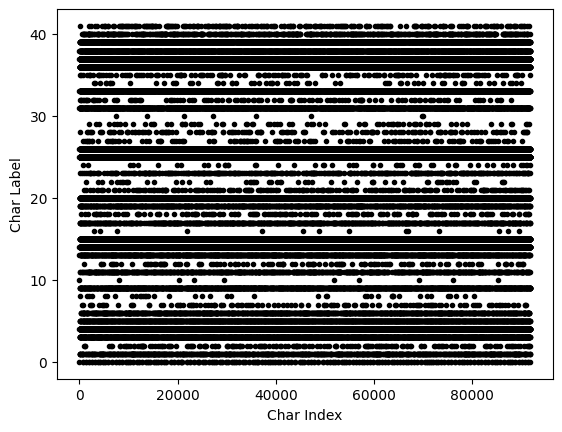

In [277]:
plt.plot(data.cpu().numpy(),'k.')
plt.xlabel('Char Index')
plt.ylabel('Char Label')
plt.show()

# LSTM

## Model Class

In [278]:
class LSTMnet(nn.Module):
  def __init__(self, input_size, output_size, hidden_size, layers_num):
    super().__init__()

    self.input_size  = input_size
    self.output_size = output_size
    self.hidden_size = hidden_size
    self.layers_num  = layers_num

    self.embeddings = nn.Embedding(input_size, input_size)

    self.lstm = nn.LSTM(input_size, hidden_size, layers_num)

    self.out  = nn.Linear(hidden_size, output_size)

  def forward(self, x, h=None):

    x    = self.embeddings(x)
    y, h = self.lstm(x, h)
    y    = self.out(y)

    return y, (h[0], h[1])

In [279]:
input_size  = len(vocab)
output_size = len(vocab)

hidden_size = 512
seq_len     = 80
layers_num  = 3
epochs      = 3

In [280]:
lstm = LSTMnet(input_size, output_size, hidden_size, layers_num).to(device)

loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm.parameters(), lr = 3e-4)

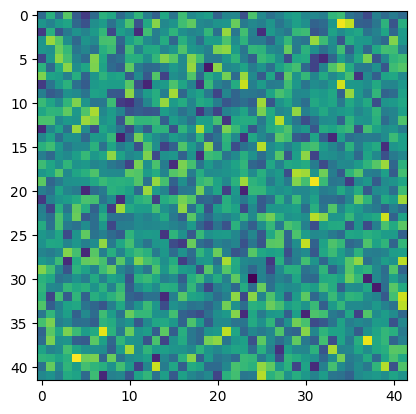

In [281]:
I = next(lstm.embeddings.named_parameters())
plt.imshow(I[1].cpu().detach().numpy())
plt.show()

## Train The Model

In [282]:
data

tensor([ 0, 10, 31,  ..., 14,  5,  0], device='cuda:0')

In [283]:
lstm.to(device)

LSTMnet(
  (embeddings): Embedding(42, 42)
  (lstm): LSTM(42, 512, num_layers=3)
  (out): Linear(in_features=512, out_features=42, bias=True)
)

In [284]:
losses = np.zeros(epochs)

for epoch in range(epochs):

  txt_loss = 0
  hidden_state = None

  for txtloc in range(0, len(txt)-seq_len):

    x = data[txtloc   : txtloc + seq_len]
    y = data[txtloc+1 : txtloc + seq_len + 1]

    output, hidden_state = lstm(x,hidden_state)
    hidden_state = (hidden_state[0].detach(), hidden_state[1].detach())

    output = output.view(-1, output_size)
    y = y.view(-1)

    loss = loss_fn(output, y)
    txt_loss += loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if txtloc % 500 == 0:
      msg = f'Epoch {epoch+1}/{epochs} | step {txtloc} | loss {loss.item():.4f}'
      sys.stdout.write('\r' + msg)

  losses[epoch] = txt_loss / txtloc

  print(f'\nEpoch {epoch+1} done | avg loss {losses[epoch]:.4f}')

Epoch 1/3 | step 91500 | loss 0.1440
Epoch 1 done | avg loss 0.1906
Epoch 2/3 | step 91500 | loss 0.1243
Epoch 2 done | avg loss 0.1636
Epoch 3/3 | step 91500 | loss 0.1219
Epoch 3 done | avg loss 0.1640


# Eval

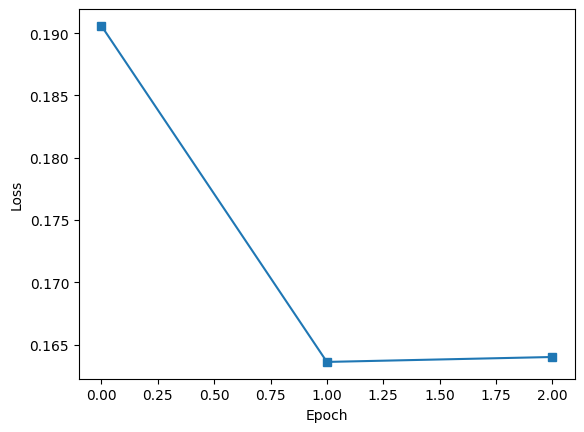

In [285]:
plt.plot(losses, 's-')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Generate new lorem ipsum

Take the last seq_len

In [286]:
x = data[-seq_len:]
t = ''
for l in x:
  t += idx_to_let[l.item()]
t

'augue nisl, ut aliquam neque euismod sed. Ut tincidunt id diam egestas sodales.\n'

In [287]:
lorem_length = 300

# random char from data to begin
x = torch.tensor(let_to_idx['d']).view(1,1).to(device)
lorem = idx_to_let[x.item()]
lorem, x

('d', tensor([[9]], device='cuda:0'))

In [288]:
# initialize the hidden
hidden_state = None
# generate text
for i in range(lorem_length):
  output, hidden_state = lstm(x, hidden_state)

  # get the max output and replace inputd data
  index = torch.argmax(output).item()
  x[0][0] = index

  # append that output to the text
  lorem += idx_to_let[index]

lorem

'diam lorem quam ultrices massa, ullamcorper sit amet hendrerit id, feugiat et quam. Suspendisse blandit augue nisl, ut aliquam neque euismod sed. Ut tincidunt id diam egestas sodales feugiat et quam. Suspendisse blandit augue nisl, ut aliquam neque euismod sed. Ut tincidunt id diam egestas sodales fe'

Let's take last seq_len of train data, to start prediction from that.

In [289]:
x = data[-seq_len:]
t = ''

for l in x:
  t += idx_to_let[l.item()]

x, t

(tensor([15, 26, 17, 26, 37, 25, 20,  4, 14, 39, 19, 25, 26, 36, 25, 15, 39,  4,
          1, 26, 15, 38, 25, 20, 37,  1, 26, 37, 25, 37, 26,  4, 14, 38, 31,  9,
         25, 14, 37,  9,  5, 25, 24, 36, 25, 36,  4, 20,  3,  4,  9, 26, 20, 36,
         25,  4,  9, 25,  9,  4, 15, 38, 25, 37, 17, 37, 14, 36, 15, 14, 25, 14,
         31,  9, 15, 39, 37, 14,  5,  0], device='cuda:0'),
 'augue nisl, ut aliquam neque euismod sed. Ut tincidunt id diam egestas sodales.\n')

Let's take 1 random letter

In [290]:
x = torch.tensor(let_to_idx['n']).view(1,1).to(device)
lorem = idx_to_let[x.item()]

x, lorem

(tensor([[20]], device='cuda:0'), 'n')

Now prediction

In [291]:
lorem_length = 300

hidden_state = None

for i in range(lorem_length):

  # model pred
  y, hidden_state = lstm(x, hidden_state)

  # take highest pred
  index = torch.argmax(y).item()

  # replace last letter
  x[0][0] = index

  # append text
  lorem += idx_to_let[index]

lorem

'nisl, ut aliquam neque euismod sed. Ut tincidunt id diam egestas sodales feugiat et quam. Suspendisse blandit augue nisl, ut aliquam neque euismod sed. Ut tincidunt id diam egestas sodales feugiat et quam. Suspendisse blandit augue nisl, ut aliquam neque euismod sed. Ut tincidunt id diam egestas soda'

# Plot

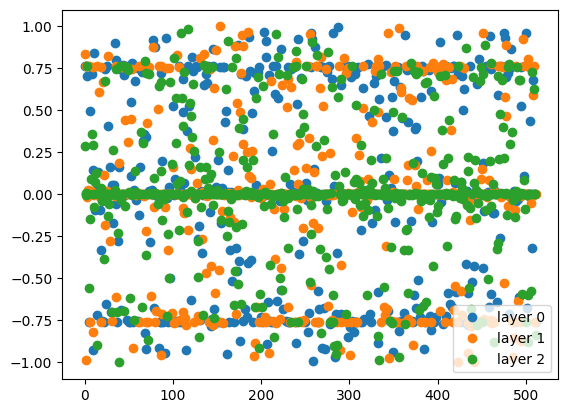

In [292]:
for i in range(layers_num):
  plt.plot(hidden_state[0][i,0,:].cpu().detach().numpy(), 'o', label = f'layer {i}')
  plt.legend()
plt.show()

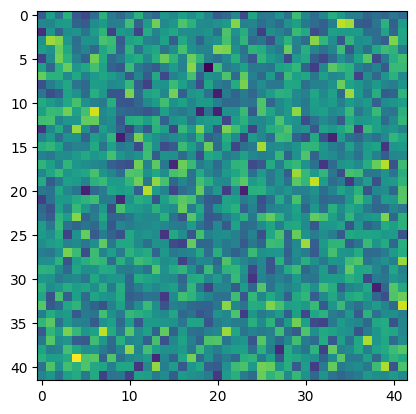

In [293]:
I = next(lstm.embeddings.named_parameters())
I = I[1].cpu().detach().numpy()
plt.imshow(I)
plt.show()

## PCA

/tmp/ipykernel_7792/4059740880.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_yticklabels(let_to_idx.keys())


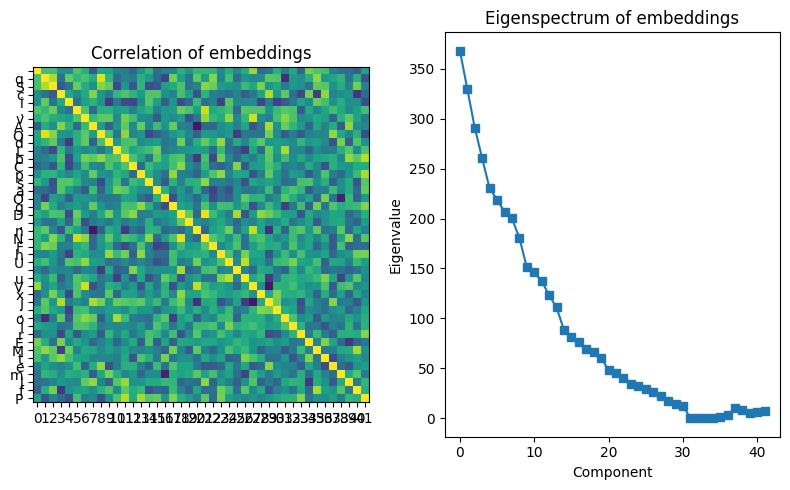

In [294]:
# FYI, lots can be done with this matrix e.g. PCA
d, V = np.linalg.eig(I@I.T)

fig, axs = plt.subplots(1,2,figsize=(8,5))
axs[0].imshow(np.corrcoef(I), vmin = -.5, vmax = .5)
axs[0].set_title('Correlation of embeddings')
axs[0].set_xticks(range(len(let_to_idx.keys())))
axs[0].set_yticklabels(let_to_idx.keys())
axs[0].set_yticks(range(len(let_to_idx.keys())))
axs[0].set_yticklabels(let_to_idx.keys())

axs[1].plot(d, 's-')
axs[1].set_xlabel('Component')
axs[1].set_ylabel('Eigenvalue')
axs[1].set_title('Eigenspectrum of embeddings')

plt.tight_layout()
plt.show()